# Solar Panel Soiling Risk — Final Framework
## Data-Driven Binary Classification via K-Means Clustering
### Cairo & Aswan, Egypt | 2019-2023
---
**Pipeline:**
1. Load & Preprocess
2. Feature Engineering
3. K-Means Clustering
4. Binary Classification  
5. Ablation  
6. Uncertainty
7. Seasonal Analysis  
8. Economic Analysis  
9. Deployment

In [1]:
!pip install xgboost lightgbm gradio requests statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score,
    silhouette_score, brier_score_loss)
from sklearn.calibration import calibration_curve # Corrected import
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar
import xgboost as xgb
import lightgbm as lgb
import warnings, os
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import xarray
import xarray as xr

# Step 3: Load datasets
ds1 = xr.open_dataset('/content/drive/MyDrive/solar panel/EAR5-2019-2020/data_stream-oper_stepType-instant.nc')
ds2 = xr.open_dataset('/content/drive/MyDrive/solar panel/EAR5-2019-2020/data_stream-oper_stepType-accum.nc')

# Step 4: Print summaries for screenshot
print("="*50)
print("INSTANT FILE SUMMARY")
print("="*50)
print(ds1)

print("\nVariables in INSTANT file:")
print(list(ds1.data_vars))

print("\nDimensions:")
print(ds1.dims)


print("\n" + "="*50)
print("ACCUM FILE SUMMARY")
print("="*50)
print(ds2)

print("\nVariables in ACCUM file:")
print(list(ds2.data_vars))

print("\nDimensions:")
print(ds2.dims)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INSTANT FILE SUMMARY
<xarray.Dataset> Size: 47MB
Dimensions:     (valid_time: 1462, latitude: 41, longitude: 49)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 12kB 2019-01-01 ... 2020-12-31T12...
  * latitude    (latitude) float64 328B 32.0 31.75 31.5 ... 22.5 22.25 22.0
  * longitude   (longitude) float64 392B 25.0 25.25 25.5 ... 36.5 36.75 37.0
    number      int64 8B ...
    expver      (valid_time) <U4 23kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 12MB ...
    v10         (valid_time, latitude, longitude) float32 12MB ...
    d2m         (valid_time, latitude, longitude) float32 12MB ...
    t2m         (valid_time, latitude, longitude) float32 12MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0

## Step 1 — Load & Preprocess Data

In [3]:
import xarray as xr
BASE_PATH = '/content/drive/MyDrive/solar panel/'

CAIRO_LAT, CAIRO_LON = 30.06, 31.24
ASWAN_LAT, ASWAN_LON = 24.09, 32.90

START_DATE = '2019-01-01'
END_DATE   = '2023-12-31'

In [4]:
import xarray as xr
BASE_PATH = '/content/drive/MyDrive/solar panel/'

CAIRO_LAT, CAIRO_LON = 30.06, 31.24
ASWAN_LAT, ASWAN_LON = 24.09, 32.90

START_DATE = '2019-01-01'
END_DATE   = '2023-12-31'

# PVGIS loader
def load_pvgis(files, city, start, end):
    dfs = []
    for f in files:
        if not os.path.exists(f): continue
        with open(f) as fh: lines = fh.readlines()
        data_end = len(lines)
        for i in range(len(lines)-1, 0, -1):
            if lines[i].strip() and lines[i][0].isdigit():
                data_end = i + 1; break
        footer = len(lines) - data_end
        df = pd.read_csv(f, skiprows=10,
                         skipfooter=footer+2, engine='python')
        df['time'] = pd.to_datetime(
            df['time'].astype(str).str[:8], format='%Y%m%d')
        df = df[(df['time']>=start)&(df['time']<=end)]
        if len(df)==0: continue
        df = df.rename(columns={
            'P':'pv_power','Gb(i)':'irradiance_direct',
            'Gd(i)':'irradiance_diffuse',
            'Gr(i)':'irradiance_reflected',
            'H_sun':'sun_elevation'})
        df = df[df.get('sun_elevation', pd.Series([1]*len(df))) > 0]
        df = df.drop(columns=['T2m','WS10m','Int'], errors='ignore')
        df = df.set_index('time')
        agg = {c:'sum' if c=='pv_power' else 'mean'
               for c in df.columns if c in
               ['pv_power','irradiance_direct','irradiance_diffuse',
                'irradiance_reflected','sun_elevation']}
        dfs.append(df.resample('D').agg(agg).reset_index())
    out = pd.concat(dfs).drop_duplicates('time')            .sort_values('time').reset_index(drop=True)
    out['city'] = city
    return out

#  ERA5 loader
def load_era5(folders, lat, lon, city, start, end):
    all_dfs = []
    for folder in folders:
        if not os.path.exists(folder):
            print(f"Warning: Folder not found: {folder}")
            continue
        files = [os.path.join(folder,f)
                 for f in os.listdir(folder) if f.endswith('.nc')]
        if not files:
            print(f"Warning: No .nc files found in: {folder}")
            continue
        city_dfs = []
        for f in sorted(files):
            try:
                ds = xr.open_dataset(f, engine='h5netcdf')
                ds.attrs.pop('history', None)
                dc = ds.sel(latitude=lat, longitude=lon, method='nearest')
                df = dc.to_dataframe().reset_index()
                tc = 'valid_time' if 'valid_time' in df.columns else 'time'
                df = df.rename(columns={tc:'time'})
                df['time'] = pd.to_datetime(df['time'])
                df = df.drop(columns=['number','expver','latitude',
                    'longitude','step','surface'], errors='ignore')
                city_dfs.append(df)
                ds.close()
            except Exception as e:
                print(f"Error processing file {f}: {e}")
                pass
        if not city_dfs: continue
        df = city_dfs[0]
        for d2 in city_dfs[1:]:
            new = [c for c in d2.columns if c not in df.columns or c=='time']
            df = df.merge(d2[new], on='time', how='outer')
        df = df[(df['time']>=start)&(df['time']<=end)]               .sort_values('time').drop_duplicates('time').reset_index(drop=True)
        if 'u10' in df.columns and 'v10' in df.columns:
            df['wind_speed'] = np.sqrt(df['u10']**2+df['v10']**2)
            df['wind_direction'] = (np.degrees(
                np.arctan2(df['u10'],df['v10']))+360)%360
        if 'd2m' in df.columns and 't2m' in df.columns:
            df['relative_humidity'] = 100*(
                np.exp(17.625*(df['d2m']-273.15)/(243.04+df['d2m']-273.15))/
                np.exp(17.625*(df['t2m']-273.15)/(243.04+df['t2m']-273.15)))
            df['dewpoint_celsius'] = df['d2m'] - 273.15 # Calculate dewpoint in Celsius
        if 't2m' in df.columns:
            df['temperature_celsius'] = df['t2m']-273.15
        df = df.replace([np.inf,-np.inf],np.nan)               .fillna(method='ffill').fillna(method='bfill')
        agg = {c:('sum' if c=='tp' else 'mean')
               for c in ['tp','wind_speed','wind_direction',
                         'relative_humidity','temperature_celsius',
                         'dewpoint_celsius', # Add dewpoint to aggregation
                         'u10','v10'] if c in df.columns}
        df = df.set_index('time')
        df = df.resample('D').agg(agg).reset_index()
        df['city'] = city
        all_dfs.append(df)
    combined = pd.concat(all_dfs).drop_duplicates('time')                 .sort_values('time').reset_index(drop=True)
    print(f'  {city} ERA5: {len(combined)} rows | '
          f'nulls={combined.isnull().sum().sum()}')
    return combined

#  CAMS loader
def load_cams(folders, lat, lon, city, start, end):
    all_dfs = []
    for folder in folders:
        if not os.path.exists(folder): continue
        files = [os.path.join(folder,f)
                 for f in os.listdir(folder) if f.endswith('.nc')]
        dfs = []
        for f in sorted(files):
            try:
                ds = xr.open_dataset(f, engine='h5netcdf')
                dc = ds.sel(latitude=lat, longitude=lon, method='nearest')
                df = dc.to_dataframe().reset_index()
                dfs.append(df); ds.close()
            except: pass
        if not dfs: continue
        df = pd.concat(dfs, ignore_index=True)
        if 'valid_time' in df.columns:
            df = df.rename(columns={'valid_time':'time'})
        df['time'] = pd.to_datetime(df['time'])
        df = df[(df['time']>=start)&(df['time']<=end)]
        df = df.drop(columns=['latitude','longitude',
            'forecast_period','forecast_reference_time'],errors='ignore')
        df = df.drop_duplicates('time').sort_values('time').reset_index(drop=True)
        if 'pm2p5' in df.columns:
            df['pm25_ugm3'] = df['pm2p5']*1e9; df=df.drop(columns=['pm2p5'])
        if 'pm10'  in df.columns:
            df['pm10_ugm3'] = df['pm10']*1e9;  df=df.drop(columns=['pm10'])
        if 'duaod550' in df.columns:
            df = df.rename(columns={'duaod550':'dust_aod'})
        df = df.replace([np.inf,-np.inf],np.nan)               .fillna(method='ffill').fillna(method='bfill')
        df = df.set_index('time').resample('D').mean().reset_index()
        df['city'] = city
        all_dfs.append(df)
    combined = pd.concat(all_dfs).drop_duplicates('time')                 .sort_values('time').reset_index(drop=True)
    print(f'  {city} CAMS: {len(combined)} rows | '
          f'dust={combined["dust_aod"].min():.4f}-{combined["dust_aod"].max():.4f}')
    return combined

# Run loaders
print('Loading PVGIS...')
cairo_pv = load_pvgis([BASE_PATH+'PVGIS-Cairo-2019.csv',
                       BASE_PATH+'PVGIS-Cairo-2020-2023.csv'],
                       'Cairo', START_DATE, END_DATE)
aswan_pv = load_pvgis([BASE_PATH+'PVGIS-Aswan-2019.csv',
                       BASE_PATH+'PVGIS-Aswan-2020-2023.csv'],
                       'Aswan', START_DATE, END_DATE)

print('Loading ERA5...')
ERA5 = [
    BASE_PATH + 'EAR5-2019-2020/',
    BASE_PATH + 'EAR5-2021-2023/',
    BASE_PATH + 'EAR5-2024-2025/',
]

#ERA5 = [BASE_PATH+'ERA5-2019-2020/',BASE_PATH+'ERA5-2021-2023/',BASE_PATH+'ERA5-2024-2025/'] # Corrected folder names
cairo_e5 = load_era5(ERA5, CAIRO_LAT, CAIRO_LON, 'Cairo', START_DATE, END_DATE)
aswan_e5 = load_era5(ERA5, ASWAN_LAT, ASWAN_LON, 'Aswan', START_DATE, END_DATE)

print('Loading CAMS...')
CAMS = [BASE_PATH+'CAMS-2019-2021/',BASE_PATH+'CAMS-2023-2022/',BASE_PATH+'CAMS-2024-2025/']
cairo_cm = load_cams(CAMS, CAIRO_LAT, CAIRO_LON, 'Cairo', START_DATE, END_DATE)
aswan_cm = load_cams(CAMS, ASWAN_LAT, ASWAN_LON, 'Aswan', START_DATE, END_DATE)

def merge_city(pv, e5, cm, city):
    df = pv.merge(e5,  on=['time','city'], how='inner')
    df = df.merge(cm,  on=['time','city'], how='inner')
    df = df.drop_duplicates('time').sort_values('time').reset_index(drop=True)
    df = df.drop(columns=['temperature_pvgis','wind_speed_pvgis'],errors='ignore')
    print(f'  {city}: {len(df)} rows | nulls={df.isnull().sum().sum()}')
    return df

cairo_df = merge_city(cairo_pv, cairo_e5, cairo_cm, 'Cairo')
aswan_df = merge_city(aswan_pv, aswan_e5, aswan_cm, 'Aswan')
full_df  = pd.concat([cairo_df,aswan_df],ignore_index=True)             .sort_values(['city','time']).reset_index(drop=True)
full_df.to_csv(BASE_PATH+'clean_data_2019_2023.csv', index=False)
print(f'\n Final: {len(full_df)} rows \u00d7 {len(full_df.columns)} cols')
print(full_df.isnull().sum().sum(), 'nulls')

Loading PVGIS...
Loading ERA5...
  Cairo ERA5: 1826 rows | nulls=0
  Aswan ERA5: 1826 rows | nulls=0
Loading CAMS...
  Cairo CAMS: 1825 rows | dust=0.0003-0.8050
  Aswan CAMS: 1825 rows | dust=0.0090-0.8100
  Cairo: 1825 rows | nulls=0
  Aswan: 1825 rows | nulls=0

 Final: 3650 rows × 18 cols
0 nulls


In [5]:
df=pd.read_csv(BASE_PATH+'clean_data_2019_2023.csv')
df.head()

,time,pv_power,irradiance_direct,irradiance_diffuse,irradiance_reflected,sun_elevation,city,tp,wind_speed,wind_direction,relative_humidity,temperature_celsius,dewpoint_celsius,u10,v10,dust_aod,pm25_ugm3,pm10_ugm3
0,2019-01-01,3266.31,192.308,213.588,5.890,28.108,Aswan,0.0,3.055558,162.83495,47.595577,17.302399,5.838287,0.757896,-2.515564,0.030978,24.225090,35.103645
1,2019-01-02,5367.65,502.231,161.532,8.179,28.168,Aswan,0.0,4.295223,150.45490,36.418240,16.808868,1.437897,1.970818,-3.383057,0.048328,24.610065,36.621390
2,2019-01-03,5661.68,539.012,157.043,8.512,28.235,Aswan,0.0,2.539201,149.55170,36.716064,16.285187,1.116364,0.432938,-2.203110,0.169789,72.473630,116.861465
3,2019-01-04,5662.78,546.565,156.761,8.511,28.307,Aswan,0.0,3.879791,210.63736,35.387830,17.034332,1.150299,-1.985809,-3.329979,0.128386,75.915190,96.317120
4,2019-01-05,5192.90,456.939,187.779,8.059,28.386,Aswan,0.0,4.166710,173.12567,31.390617,17.934113,0.345612,0.412781,-4.023384,0.095524,62.231660,78.969630


## Step 2 — Feature Engineering & Train/Test Split

In [6]:
full_df = pd.read_csv(BASE_PATH+'clean_data_2019_2023.csv')
full_df['time'] = pd.to_datetime(full_df['time'])

#  Split FIRST (no leakage)
train_df = full_df[full_df['time'] < '2023-01-01'].copy().reset_index(drop=True)
test_df  = full_df[full_df['time'] >= '2023-01-01'].copy().reset_index(drop=True)
print(f'Train: {len(train_df)} | Test: {len(test_df)}')

#Engineer features per city
def engineer(df):
    out = []
    for city in ['Cairo','Aswan']:
        d = df[df['city']==city].copy().sort_values('time').reset_index(drop=True)
        # Temporal
        d['month']           = d['time'].dt.month
        d['season_encoded']  = d['month'].apply(
            lambda m: 0 if m in[12,1,2] else 1 if m in[3,4,5]
            else 2 if m in[6,7,8] else 3)
        d['khamaseen_flag']  = d['month'].isin([3,4,5]).astype(int)
        # Wind rolling
        d['wind_speed_3d']   = d['wind_speed'].rolling(3,min_periods=1).mean()
        d['wind_speed_7d']   = d['wind_speed'].rolling(7,min_periods=1).mean()
        d['wind_speed_14d']  = d['wind_speed'].rolling(14,min_periods=1).mean()
        d['wind_speed_max_3d']= d['wind_speed'].rolling(3,min_periods=1).max()
        # Humidity
        d['humidity_7d_avg'] = d['relative_humidity'].rolling(7,min_periods=1).mean()
        d['dew_flag']        = (d['relative_humidity']>85).astype(int)
        # Precip
        d['precip_7d_sum']   = d['tp'].rolling(7,min_periods=1).sum()
        dsr,cnt = [],0
        for v in d['tp']:
            cnt = 0 if v>0.0001 else cnt+1
            dsr.append(cnt)
        d['days_since_rain'] = dsr
        # Temperature
        d['temp_variability']= d['temperature_celsius'].rolling(7,min_periods=2).std().fillna(0)
        d['heatwave_flag']   = (d['temperature_celsius']>38).astype(int)
        # Irradiance derived
        d['irradiance_diffuse']   = d['irradiance_direct']*0.15
        d['irradiance_reflected'] = d['irradiance_direct']*0.05
        # City encoding
        d['city_encoded'] = 1 if city=='Cairo' else 0
        out.append(d)
    return pd.concat(out,ignore_index=True).sort_values(['city','time']).reset_index(drop=True)

train_df = engineer(train_df)
test_df  = engineer(test_df)

EXCLUDE  = ['time','city','season','dust_aod']
FEATURES = [c for c in train_df.columns if c not in EXCLUDE]
print(f'Features: {len(FEATURES)}')
print(FEATURES)

train_df.to_csv(BASE_PATH+'train_engineered.csv', index=False)
test_df.to_csv( BASE_PATH+'test_engineered.csv',  index=False)

Train: 2920 | Test: 730
Features: 29
['pv_power', 'irradiance_direct', 'irradiance_diffuse', 'irradiance_reflected', 'sun_elevation', 'tp', 'wind_speed', 'wind_direction', 'relative_humidity', 'temperature_celsius', 'dewpoint_celsius', 'u10', 'v10', 'pm25_ugm3', 'pm10_ugm3', 'month', 'season_encoded', 'khamaseen_flag', 'wind_speed_3d', 'wind_speed_7d', 'wind_speed_14d', 'wind_speed_max_3d', 'humidity_7d_avg', 'dew_flag', 'precip_7d_sum', 'days_since_rain', 'temp_variability', 'heatwave_flag', 'city_encoded']


In [7]:
train_df=pd.read_csv(BASE_PATH+'train_engineered.csv')
train_df.head()

,time,pv_power,irradiance_direct,irradiance_diffuse,irradiance_reflected,sun_elevation,city,tp,wind_speed,wind_direction,...,wind_speed_7d,wind_speed_14d,wind_speed_max_3d,humidity_7d_avg,dew_flag,precip_7d_sum,days_since_rain,temp_variability,heatwave_flag,city_encoded
0,2019-01-01,3266.31,192.308,28.84620,9.61540,28.108,Aswan,0.0,3.055558,162.83495,...,3.055558,3.055558,3.055558,47.595577,0,0.0,1,0.000000,0,0
1,2019-01-02,5367.65,502.231,75.33465,25.11155,28.168,Aswan,0.0,4.295223,150.45490,...,3.675390,3.675390,4.295223,42.006909,0,0.0,2,0.348979,0,0
2,2019-01-03,5661.68,539.012,80.85180,26.95060,28.235,Aswan,0.0,2.539201,149.55170,...,3.296661,3.296661,4.295223,40.243294,0,0.0,3,0.508680,0,0
3,2019-01-04,5662.78,546.565,81.98475,27.32825,28.307,Aswan,0.0,3.879791,210.63736,...,3.442443,3.442443,4.295223,39.029428,0,0.0,4,0.431707,0,0
4,2019-01-05,5192.90,456.939,68.54085,22.84695,28.386,Aswan,0.0,4.166710,173.12567,...,3.587297,3.587297,4.166710,37.501666,0,0.0,5,0.609518,0,0


## Step 3 — K-Means Clustering → Discover Binary Boundary

K  Silhouette
--------------------
K=2  0.6625  ← BEST
K=3  0.6282
K=4  0.6039

Optimal K = 2
K=2 centers: 0.0639, 0.2693
K=2 boundary: 0.1666

Train distribution:
risk_binary
CLEAN     2160
SOILED     760
Name: count, dtype: int64

Test distribution:
risk_binary
CLEAN     534
SOILED    196
Name: count, dtype: int64


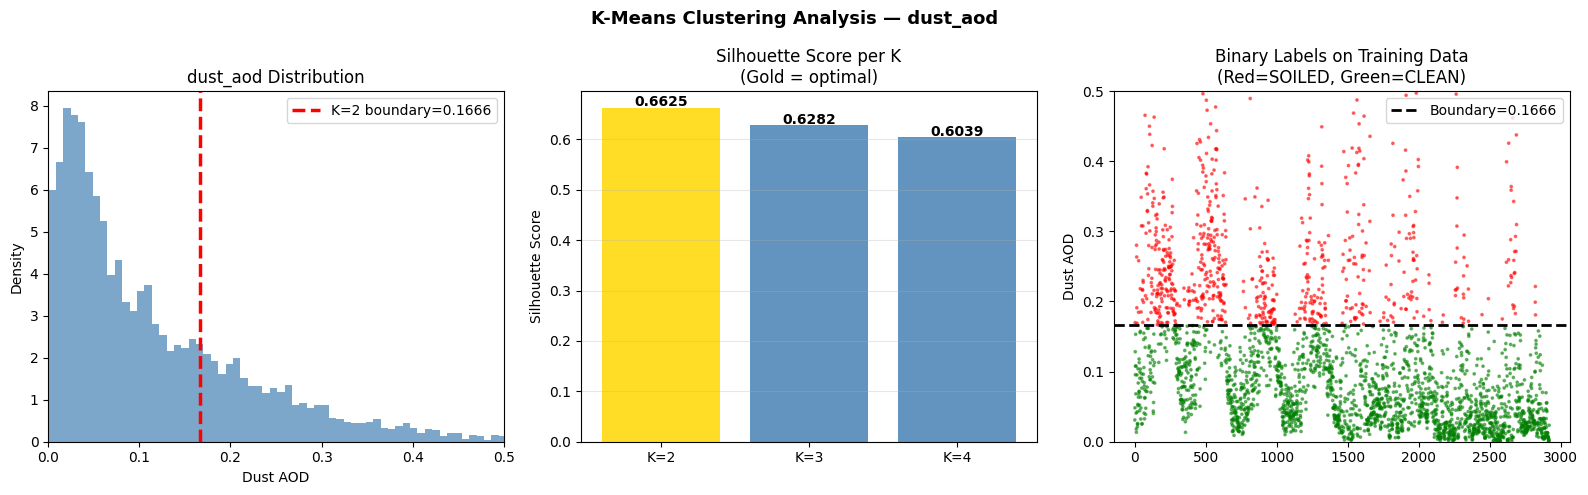

In [8]:
train_df = pd.read_csv(BASE_PATH+'train_engineered.csv')
test_df  = pd.read_csv(BASE_PATH+'test_engineered.csv')
train_df['time'] = pd.to_datetime(train_df['time'])
test_df['time']  = pd.to_datetime(test_df['time'])

aod_all = pd.concat([train_df['dust_aod'],
                     test_df['dust_aod']]).values
aod_2d  = aod_all.reshape(-1,1)

# Find optimal K
print('K  Silhouette')
print('-'*20)
sil = {}
for k in [2,3,4]:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(aod_2d)
    s   = silhouette_score(aod_2d, lbl)
    sil[k] = s
    print(f'K={k}  {s:.4f}{"  ← BEST" if k==min(sil,key=lambda x:abs(sil[x]-max(sil.values()))) else ""}')

best_k = max(sil, key=sil.get)
print(f'\nOptimal K = {best_k}')

# K=2 boundary
km2      = KMeans(n_clusters=2, random_state=42, n_init=20)
km2.fit(aod_2d)
centers2 = sorted(km2.cluster_centers_.flatten())
K2_BOUNDARY = (centers2[0]+centers2[1])/2
print(f'K=2 centers: {centers2[0]:.4f}, {centers2[1]:.4f}')
print(f'K=2 boundary: {K2_BOUNDARY:.4f}')

# Apply labels
def apply_labels(df, boundary):
    df = df.copy()
    df['risk_binary'] = (df['dust_aod'] >= boundary)                        .map({True:'SOILED',False:'CLEAN'})
    return df

train_df = apply_labels(train_df, K2_BOUNDARY)
test_df  = apply_labels(test_df,  K2_BOUNDARY)

print('\nTrain distribution:')
print(train_df['risk_binary'].value_counts())
print('\nTest distribution:')
print(test_df['risk_binary'].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(16,5))
fig.suptitle('K-Means Clustering Analysis — dust_aod',
             fontsize=13, fontweight='bold')

axes[0].hist(aod_all, bins=100, color='steelblue',
             alpha=0.7, density=True)
axes[0].axvline(K2_BOUNDARY, color='red', linewidth=2.5,
                linestyle='--', label=f'K=2 boundary={K2_BOUNDARY:.4f}')
axes[0].set_xlabel('Dust AOD'); axes[0].set_ylabel('Density')
axes[0].set_title('dust_aod Distribution'); axes[0].legend()
axes[0].set_xlim(0,0.5)


axes[1].bar([f'K={k}' for k in sil.keys()], sil.values(),
            color=['gold' if k==best_k else 'steelblue'
                   for k in sil.keys()], alpha=0.85)
for i,(k,v) in enumerate(sil.items()):
    axes[1].text(i, v+0.003, f'{v:.4f}',
                 ha='center', fontweight='bold')
axes[1].set_title('Silhouette Score per K\n(Gold = optimal)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(axis='y', alpha=0.3)

colors = [('red' if r=='SOILED' else 'green')
          for r in train_df['risk_binary']]
axes[2].scatter(range(len(train_df)),
                train_df['dust_aod'],
                c=colors, s=3, alpha=0.5)
axes[2].axhline(K2_BOUNDARY, color='black',
                linewidth=2, linestyle='--',
                label=f'Boundary={K2_BOUNDARY:.4f}')
axes[2].set_title('Binary Labels on Training Data\n(Red=SOILED, Green=CLEAN)')
axes[2].set_ylabel('Dust AOD'); axes[2].legend()
axes[2].set_ylim(0,0.5)

plt.tight_layout()
plt.savefig(BASE_PATH+'step3_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

train_df.to_csv(BASE_PATH+'train_binary.csv', index=False)
test_df.to_csv( BASE_PATH+'test_binary.csv',  index=False)


In [9]:
train_binary=pd.read_csv(BASE_PATH+'train_binary.csv')
train_binary.head()

,time,pv_power,irradiance_direct,irradiance_diffuse,irradiance_reflected,sun_elevation,city,tp,wind_speed,wind_direction,...,wind_speed_14d,wind_speed_max_3d,humidity_7d_avg,dew_flag,precip_7d_sum,days_since_rain,temp_variability,heatwave_flag,city_encoded,risk_binary
0,2019-01-01,3266.31,192.308,28.84620,9.61540,28.108,Aswan,0.0,3.055558,162.83495,...,3.055558,3.055558,47.595577,0,0.0,1,0.000000,0,0,CLEAN
1,2019-01-02,5367.65,502.231,75.33465,25.11155,28.168,Aswan,0.0,4.295223,150.45490,...,3.675390,4.295223,42.006909,0,0.0,2,0.348979,0,0,CLEAN
2,2019-01-03,5661.68,539.012,80.85180,26.95060,28.235,Aswan,0.0,2.539201,149.55170,...,3.296661,4.295223,40.243294,0,0.0,3,0.508680,0,0,SOILED
3,2019-01-04,5662.78,546.565,81.98475,27.32825,28.307,Aswan,0.0,3.879791,210.63736,...,3.442443,4.295223,39.029428,0,0.0,4,0.431707,0,0,CLEAN
4,2019-01-05,5192.90,456.939,68.54085,22.84695,28.386,Aswan,0.0,4.166710,173.12567,...,3.587297,4.166710,37.501666,0,0.0,5,0.609518,0,0,CLEAN


## Step 4 — Binary Classification (Main Model)

Model                      F1      Acc      AUC      CV F1
----------------------------------------------------------
 Random Forest          90.18%   90.27%   0.9581    85.76%
 XGBoost                89.77%   89.59%   0.9592    86.53%
 LightGBM               89.09%   88.77%   0.9601    86.69%

Best: Random Forest — F1=90.18%

Full report:
              precision    recall  f1-score   support

       CLEAN       0.92      0.94      0.93       534
      SOILED       0.84      0.79      0.81       196

    accuracy                           0.90       730
   macro avg       0.88      0.87      0.87       730
weighted avg       0.90      0.90      0.90       730

Confusion Matrix:
             Pred CLEAN  Pred SOILED
True CLEAN          504           30
True SOILED          41          155

City breakdown:
  Cairo: F1=91.23%  AUC=0.9383
  Aswan: F1=88.00%  AUC=0.9593

Top 12 features:
  pm10_ugm3                      0.1857  █████████████████████████████████████
  humidity_7d_avg         

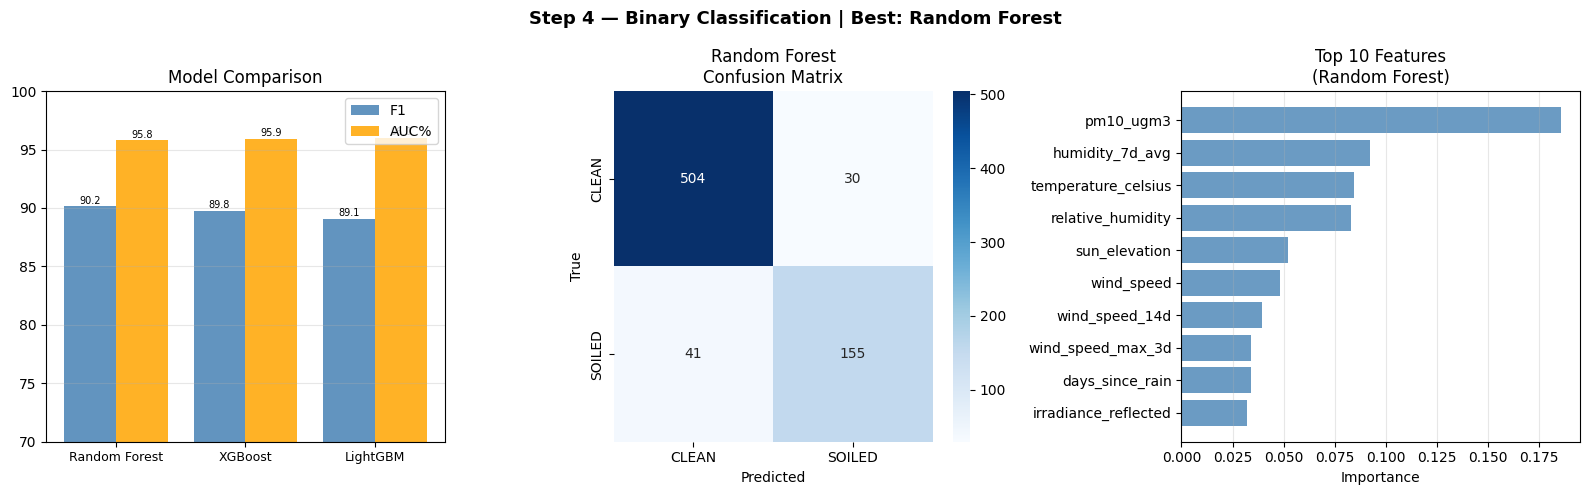

In [10]:
train_df = pd.read_csv(BASE_PATH+'train_binary.csv')
test_df  = pd.read_csv(BASE_PATH+'test_binary.csv')

EXCLUDE  = ['time','city','season','dust_aod','risk_binary']
FEATURES = [c for c in train_df.columns if c not in EXCLUDE]

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(train_df[FEATURES]), columns=FEATURES)
X_test  = pd.DataFrame(imputer.transform(test_df[FEATURES]),      columns=FEATURES)
y_train = train_df['risk_binary']
y_test  = test_df['risk_binary']

lm      = {'CLEAN':0,'SOILED':1}
lm_inv  = {0:'CLEAN',1:'SOILED'}
y_tr_e  = y_train.map(lm)
y_te_e  = y_test.map(lm)

tscv = TimeSeriesSplit(n_splits=5)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        eval_metric='logloss', verbosity=0, random_state=42),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        class_weight='balanced', verbosity=-1, random_state=42),
}

results = {}
print(f'{"Model":<20} {"F1":>8} {"Acc":>8} {"AUC":>8} {"CV F1":>10}')
print('-'*58)

for name, model in models.items():
    model.fit(X_train.values, y_tr_e)
    pred_e = model.predict(X_test.values)
    pred   = pd.Series(pred_e).map(lm_inv).values
    proba  = model.predict_proba(X_test.values)[:,1]
    f1     = f1_score(y_test, pred, average='weighted')
    acc    = accuracy_score(y_test, pred)
    auc    = roc_auc_score(y_te_e, proba)
    # CV
    cv_s = []
    for tri,vli in tscv.split(X_train):
        model.fit(X_train.values[tri], y_tr_e.values[tri])
        p = model.predict(X_train.values[vli])
        pl= pd.Series(p).map(lm_inv).values
        yl= pd.Series(y_tr_e.values[vli]).map(lm_inv).values
        cv_s.append(f1_score(yl,pl,average='weighted',zero_division=0))
    model.fit(X_train.values, y_tr_e)
    cv_mean = np.mean(cv_s)
    results[name] = {'model':model,'f1':f1,'acc':acc,
                     'auc':auc,'cv':cv_mean,'pred':pred,'proba':proba}
    print(f' {name:<20} {f1*100:>7.2f}% {acc*100:>7.2f}% '
          f'{auc:>8.4f} {cv_mean*100:>8.2f}%')

best = max(results, key=lambda x: results[x]['f1'])
print(f'\nBest: {best} — F1={results[best]["f1"]*100:.2f}%')
print('\nFull report:')
print(classification_report(y_test, results[best]['pred']))

cm = confusion_matrix(y_test, results[best]['pred'],
                      labels=['CLEAN','SOILED'])
print('Confusion Matrix:')
print(pd.DataFrame(cm,
      index=['True CLEAN','True SOILED'],
      columns=['Pred CLEAN','Pred SOILED']))

# City breakdown
print('\nCity breakdown:')
best_m = results[best]['model']
for city in ['Cairo','Aswan']:
    ct = test_df[test_df['city']==city]
    Xc = pd.DataFrame(imputer.transform(ct[FEATURES]), columns=FEATURES)
    yc = ct['risk_binary']
    pc = pd.Series(best_m.predict(Xc.values)).map(lm_inv).values
    print(f'  {city}: F1={f1_score(yc,pc,average="weighted")*100:.2f}%  '
          f'AUC={roc_auc_score(yc.map(lm),best_m.predict_proba(Xc.values)[:,1]):.4f}')

#  Feature importance
if best == 'Random Forest':
    imp = pd.Series(best_m.feature_importances_, index=FEATURES)            .sort_values(ascending=False).head(12)
    print('\nTop 12 features:')
    for f,v in imp.items():
        print(f'  {f:<30} {v:.4f}  {"█"*int(v*200)}')

fig, axes = plt.subplots(1,3, figsize=(16,5))
fig.suptitle(f'Step 4 — Binary Classification | Best: {best}',
             fontsize=13, fontweight='bold')

names = list(results.keys())
f1s   = [r['f1']*100  for r in results.values()]
aucs  = [r['auc']*100 for r in results.values()]
x     = np.arange(len(names))
axes[0].bar(x-0.2, f1s, 0.4, color='steelblue', label='F1', alpha=0.85)
axes[0].bar(x+0.2, aucs,0.4, color='orange',    label='AUC%',alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, fontsize=9)
axes[0].set_ylim(70,100); axes[0].legend()
axes[0].set_title('Model Comparison'); axes[0].grid(axis='y',alpha=0.3)
for bar,v in zip(axes[0].patches, f1s+aucs):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.2, f'{v:.1f}',
                 ha='center', fontsize=7)

sns.heatmap(cm, ax=axes[1], annot=True, fmt='d', cmap='Blues',
            xticklabels=['CLEAN','SOILED'],
            yticklabels=['CLEAN','SOILED'])
axes[1].set_title(f'{best}\nConfusion Matrix')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

imp_plot = pd.Series(
    results['Random Forest']['model'].feature_importances_,
    index=FEATURES).sort_values(ascending=False).head(10)
axes[2].barh(imp_plot.index[::-1], imp_plot.values[::-1],
             color='steelblue', alpha=0.8)
axes[2].set_title('Top 10 Features\n(Random Forest)')
axes[2].set_xlabel('Importance')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_PATH+'step4_binary_classification.png',dpi=150,bbox_inches='tight')
plt.show()

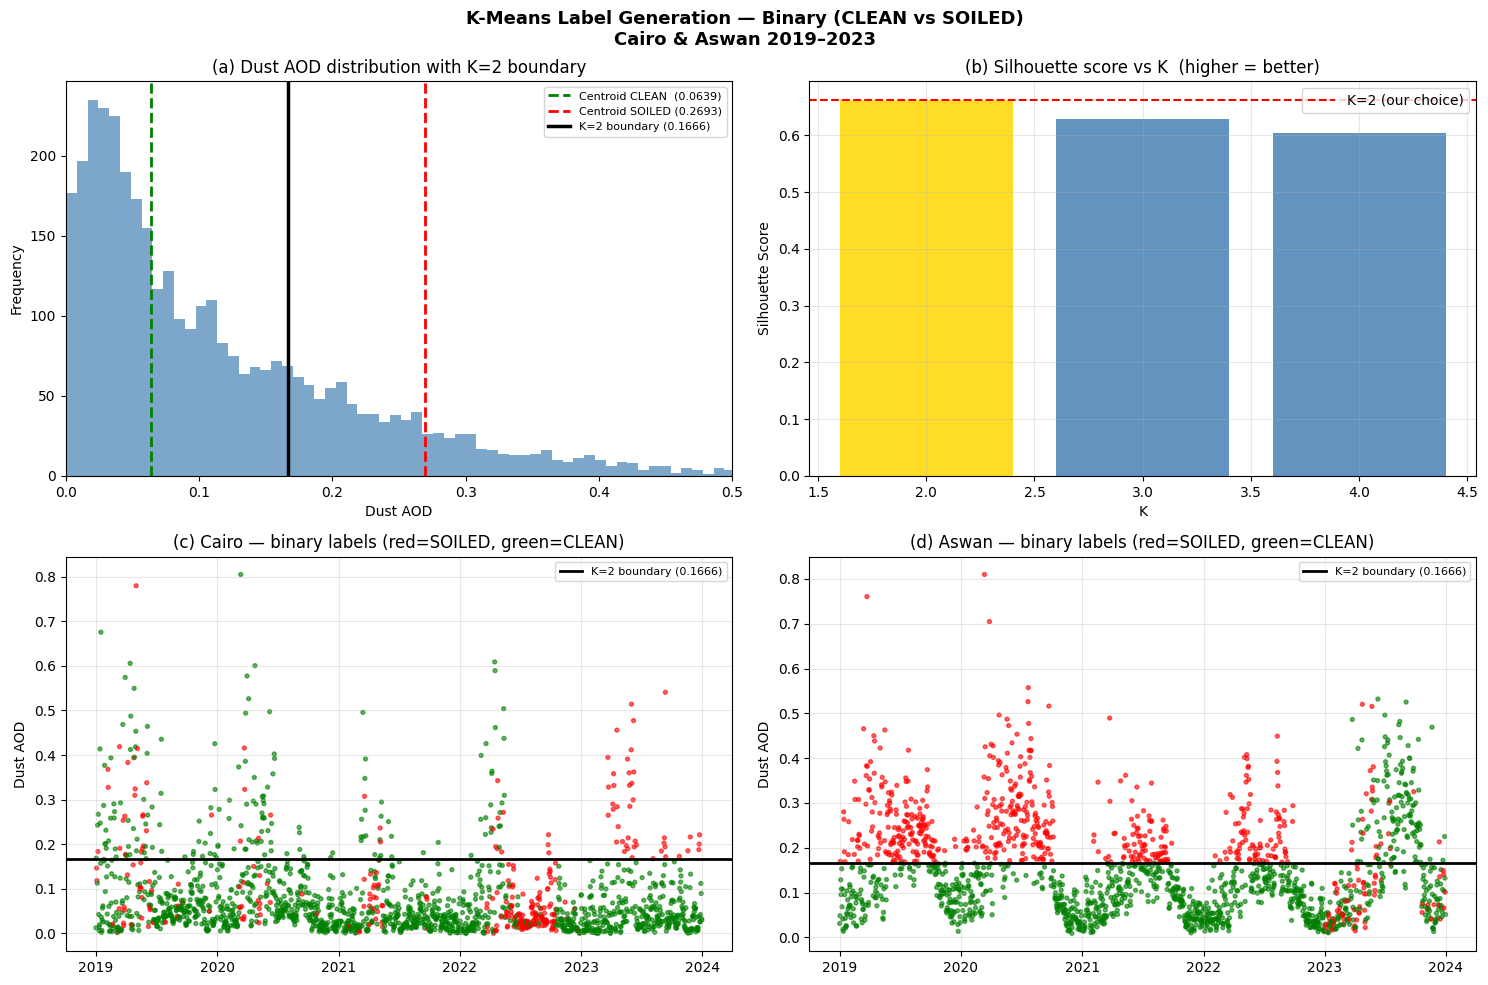


K=2 centroids : CLEAN=0.0639,  SOILED=0.2693
K=2 boundary  : 0.1666
CLEAN  :  2694  (73.8%)
SOILED :   956  (26.2%)


In [11]:
aod_2d = aod_all.reshape(-1, 1)
km2    = KMeans(n_clusters=2, random_state=42, n_init=20).fit(aod_2d)
c2     = sorted(km2.cluster_centers_.flatten())
b_k2   = (c2[0] + c2[1]) / 2          # ≈ 0.1666
l2     = (aod_2d.flatten() >= b_k2).astype(int)  # 0=CLEAN, 1=SOILED

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('K-Means Label Generation — Binary (CLEAN vs SOILED)\n'
             'Cairo & Aswan 2019–2023', fontsize=13, fontweight='bold')

# (a) Histogram with K=2 centroids + binary boundary
axes[0,0].hist(aod_all, bins=100, color='steelblue', alpha=0.7, edgecolor='none')
axes[0,0].axvline(c2[0], color='green',  linestyle='--', linewidth=2,
                  label=f'Centroid CLEAN  ({c2[0]:.4f})')
axes[0,0].axvline(c2[1], color='red',    linestyle='--', linewidth=2,
                  label=f'Centroid SOILED ({c2[1]:.4f})')
axes[0,0].axvline(b_k2,  color='black',  linestyle='-',  linewidth=2.5,
                  label=f'K=2 boundary ({b_k2:.4f})')
axes[0,0].set_title('(a) Dust AOD distribution with K=2 boundary')
axes[0,0].set_xlabel('Dust AOD'); axes[0,0].set_ylabel('Frequency')
axes[0,0].set_xlim(0, 0.5); axes[0,0].legend(fontsize=8)

# (b) Silhouette bars, K=2 highlighted
colors_sil = ['gold' if k == 2 else 'steelblue' for k in sil.keys()]
axes[0,1].bar(list(sil.keys()), list(sil.values()), color=colors_sil, alpha=0.85)
axes[0,1].axhline(list(sil.values())[0], color='red', linestyle='--', # Assuming K=2 is the first in sil.values()
                  label='K=2 (our choice)')
axes[0,1].set_title('(b) Silhouette score vs K  (higher = better)')
axes[0,1].set_xlabel('K'); axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# (c) Binary labels on training-period timeline — Cairo
cairo_mask = (full_df['city'] == 'Cairo').values
axes[1,0].scatter(full_df.loc[cairo_mask, 'time'],
                  full_df.loc[cairo_mask, 'dust_aod'],
                  c=['red' if x == 1 else 'green' for x in l2[cairo_mask]],
                  s=8, alpha=0.6)
axes[1,0].axhline(b_k2, color='black', linestyle='-', linewidth=2,
                  label=f'K=2 boundary ({b_k2:.4f})')
axes[1,0].set_title('(c) Cairo — binary labels (red=SOILED, green=CLEAN)')
axes[1,0].set_ylabel('Dust AOD'); axes[1,0].legend(fontsize=8)
axes[1,0].grid(alpha=0.3)

# (d) Binary labels on training-period timeline — Aswan
aswan_mask = (full_df['city'] == 'Aswan').values
axes[1,1].scatter(full_df.loc[aswan_mask, 'time'],
                  full_df.loc[aswan_mask, 'dust_aod'],
                  c=['red' if x == 1 else 'green' for x in l2[aswan_mask]],
                  s=8, alpha=0.6)
axes[1,1].axhline(b_k2, color='black', linestyle='-', linewidth=2,
                  label=f'K=2 boundary ({b_k2:.4f})')
axes[1,1].set_title('(d) Aswan — binary labels (red=SOILED, green=CLEAN)')
axes[1,1].set_ylabel('Dust AOD'); axes[1,1].legend(fontsize=8)
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_PATH + 'kmeans_binary_labeling.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Diagnostics
n_clean  = int((l2 == 0).sum())
n_soiled = int((l2 == 1).sum())
print(f'\nK=2 centroids : CLEAN={c2[0]:.4f},  SOILED={c2[1]:.4f}')
print(f'K=2 boundary  : {b_k2:.4f}')
print(f'CLEAN  : {n_clean:>5d}  ({100*n_clean/len(l2):.1f}%)')
print(f'SOILED : {n_soiled:>5d}  ({100*n_soiled/len(l2):.1f}%)')

In [12]:
from sklearn.ensemble import VotingClassifier

# --- 1. CV-F1–proportional weights (matches Eq. 23 in the paper) ---
cv_f1 = np.array([results[m]['cv'] for m in ['Random Forest','XGBoost','LightGBM']])
weights = cv_f1 / cv_f1.sum()
print(f'Weights  (RF, XGB, LGBM) = {weights.round(4)}')

# --- 2. Fresh base learners (clean state for the ensemble) ---
base_estimators = [
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=10,
              class_weight='balanced', random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
              eval_metric='logloss', verbosity=0, random_state=42)),
    ('lgb', lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
              class_weight='balanced', verbosity=-1, random_state=42)),
]

voting = VotingClassifier(estimators=base_estimators,
                          voting='soft', weights=weights, n_jobs=-1)

# --- 3. Fit on full training set ---
voting.fit(X_train.values, y_tr_e)

# --- 4. Test-set evaluation ---
pred_e = voting.predict(X_test.values)
pred   = pd.Series(pred_e).map(lm_inv).values
proba  = voting.predict_proba(X_test.values)[:, 1]

f1  = f1_score(y_test, pred, average='weighted')
acc = accuracy_score(y_test, pred)
auc = roc_auc_score(y_te_e, proba)

# --- 5. Time-Series CV F1 for the ensemble ---
cv_scores = []
for tri, vli in tscv.split(X_train):
    v = VotingClassifier(estimators=base_estimators,
                          voting='soft', weights=weights, n_jobs=-1)
    v.fit(X_train.values[tri], y_tr_e.values[tri])
    p  = v.predict(X_train.values[vli])
    pl = pd.Series(p).map(lm_inv).values
    yl = pd.Series(y_tr_e.values[vli]).map(lm_inv).values
    cv_scores.append(f1_score(yl, pl, average='weighted', zero_division=0))
cv_mean = float(np.mean(cv_scores))
cv_std  = float(np.std(cv_scores))

# --- 6. Store and print ---
results['Voting Ensemble'] = {
    'model': voting, 'f1': f1, 'acc': acc, 'auc': auc,
    'cv_f1': cv_mean, 'cv_std': cv_std,
    'pred': pred, 'proba': proba, 'weights': weights.tolist()
}

print(f'\nVoting Ensemble (soft, CV-F1 weighted)')
print(f'{"":<20}{"F1":>8}{"Acc":>8}{"AUC":>8}{"CV F1":>10}')
print('-'*54)
print(f'{"Voting Ensemble":<20}{f1*100:>7.2f}%{acc*100:>7.2f}%{auc:>8.4f}{cv_mean*100:>9.2f}%')

# --- 7. Per-class report ---
print('\nClassification report:')
print(classification_report(y_test, pred, digits=3))

# --- 8. Confusion matrix ---
cm = confusion_matrix(y_test, pred, labels=['CLEAN','SOILED'])
print('Confusion Matrix:')
print(pd.DataFrame(cm, index=['True CLEAN','True SOILED'],
                       columns=['Pred CLEAN','Pred SOILED']))

# --- 9. Per-city breakdown ---
print('\nPer-city performance:')
for cty in ['Cairo','Aswan']:
    mask = (test_df['city'] == cty).values
    f1c  = f1_score(y_test[mask], pred[mask], average='weighted')
    aucc = roc_auc_score(y_te_e.values[mask], proba[mask])
    print(f'  {cty}: F1={f1c*100:.2f}%  AUC={aucc:.4f}')

# --- 10. Compare against best single model ---
best_single = max(['Random Forest','XGBoost','LightGBM'],
                   key=lambda m: results[m]['f1'])
delta_f1 = (f1 - results[best_single]['f1']) * 100
print(f'\nΔF1 vs. best single ({best_single}): {delta_f1:+.2f} percentage points')

Weights  (RF, XGB, LGBM) = [0.3312 0.3341 0.3347]

Voting Ensemble (soft, CV-F1 weighted)
                          F1     Acc     AUC     CV F1
------------------------------------------------------
Voting Ensemble       90.46%  90.27%  0.9610    86.68%

Classification report:
              precision    recall  f1-score   support

       CLEAN      0.957     0.908     0.932       534
      SOILED      0.780     0.888     0.831       196

    accuracy                          0.903       730
   macro avg      0.868     0.898     0.881       730
weighted avg      0.909     0.903     0.905       730

Confusion Matrix:
             Pred CLEAN  Pred SOILED
True CLEAN          485           49
True SOILED          22          174

Per-city performance:
  Cairo: F1=93.20%  AUC=0.9431
  Aswan: F1=86.92%  AUC=0.9647

ΔF1 vs. best single (Random Forest): +0.28 percentage points


## Step 5 — Ablation Study (Validate Multi-Source Fusion)

Group                              F1     Drop Interpretation
----------------------------------------------------------------------
 Baseline (all features)        90.46% +  0.28%  Minimal
 Without PM/CAMS                86.11%  -4.07%  Important
 Without Solar/PVGIS            87.82%  -2.37%  Moderate
 Without Wind                   91.29% +  1.11%  Minimal
 Without Humidity               90.56% +  0.37%  Minimal
 Without Temperature            90.43% +  0.24%  Minimal
 Without Precipitation          90.82% +  0.63%  Minimal
 Without Temporal               90.96% +  0.78%  Minimal
 Without ERA5 (all)             91.13% +  0.94%  Minimal
 Without PVGIS (all)            87.82%  -2.37%  Moderate


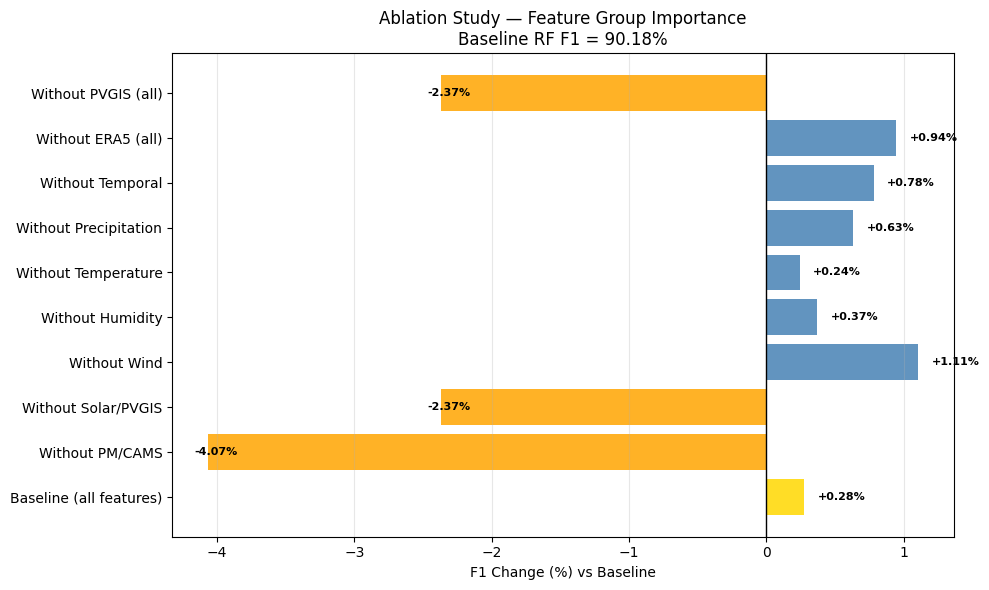

In [13]:
groups = {
    'Baseline (all features)' : [],
    'Without PM/CAMS'         : ['pm10_ugm3','pm25_ugm3'],
    'Without Solar/PVGIS'     : ['pv_power','irradiance_direct',
                                 'irradiance_diffuse','irradiance_reflected',
                                 'sun_elevation'],
    'Without Wind'            : ['wind_speed','wind_speed_3d','wind_speed_7d',
                                 'wind_speed_14d','wind_speed_max_3d'],
    'Without Humidity'        : ['relative_humidity','humidity_7d_avg','dew_flag'],
    'Without Temperature'     : ['temperature_celsius','temp_variability',
                                 'heatwave_flag'],
    'Without Precipitation'   : ['tp','days_since_rain','precip_7d_sum'],
    'Without Temporal'        : ['month','season_encoded','khamaseen_flag'],
    'Without ERA5 (all)'      : ['wind_speed','wind_speed_3d','wind_speed_7d',
                                 'wind_speed_14d','wind_speed_max_3d',
                                 'relative_humidity','humidity_7d_avg',
                                 'temperature_celsius','tp','days_since_rain',
                                 'precip_7d_sum','dew_flag','heatwave_flag',
                                 'temp_variability'],
    'Without PVGIS (all)'     : ['pv_power','irradiance_direct',
                                 'irradiance_diffuse','irradiance_reflected',
                                 'sun_elevation'],
}

baseline_f1 = results['Random Forest']['f1']
abl_results = {}

print(f'{"Group":<28} {"F1":>8} {"Drop":>8} {"Interpretation"}')
print('-'*70)

for grp, remove in groups.items():
    feats = [f for f in FEATURES if f not in remove]
    if not feats: continue
    Xtr = pd.DataFrame(imputer.fit_transform(train_df[feats]),columns=feats)
    Xte = pd.DataFrame(imputer.transform(test_df[feats]),    columns=feats)
    m   = RandomForestClassifier(n_estimators=100,max_depth=10,
                                  class_weight='balanced',
                                  random_state=42,n_jobs=-1)
    m.fit(Xtr.values, y_tr_e)
    p  = pd.Series(m.predict(Xte.values)).map(lm_inv).values
    f1 = f1_score(y_test, p, average='weighted')
    drop = (f1 - baseline_f1)*100
    sign = '+' if drop>=0 else ''
    interp = ('MOST CRITICAL' if drop < -10
              else 'Important' if drop < -3
              else 'Moderate'  if drop < -1
              else 'Minimal')
    abl_results[grp] = {'f1':f1,'drop':drop}
    print(f' {grp:<28} {f1*100:>7.2f}% {sign}{drop:>6.2f}%  {interp}')

fig, ax = plt.subplots(figsize=(10,6))
names = list(abl_results.keys())
drops = [abl_results[n]['drop'] for n in names]
colors= ['gold' if n=='Baseline (all features)'
         else 'red' if d<-5
         else 'orange' if d<-1
         else 'steelblue' for n,d in zip(names,drops)]
ax.barh(names, drops, color=colors, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('F1 Change (%) vs Baseline')
ax.set_title('Ablation Study — Feature Group Importance\n'
             f'Baseline RF F1 = {baseline_f1*100:.2f}%')
ax.grid(axis='x', alpha=0.3)
for bar,v in zip(ax.patches, drops):
    sign = '+' if v>=0 else ''
    ax.text(v+(0.1 if v>=0 else -0.1),
            bar.get_y()+bar.get_height()/2,
            f'{sign}{v:.2f}%', va='center',
            fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_PATH+'step5_ablation.png',dpi=150,bbox_inches='tight')
plt.show()

## Step 6 — Uncertainty Quantification

Confidence percentiles: 25th=0.506, 75th=0.904

Zone              n     Pct   Accuracy
--------------------------------------
 HIGH            183   25.1%       99.5%
 MODERATE        364   49.9%       95.3%
 LOW             183   25.1%       71.0%


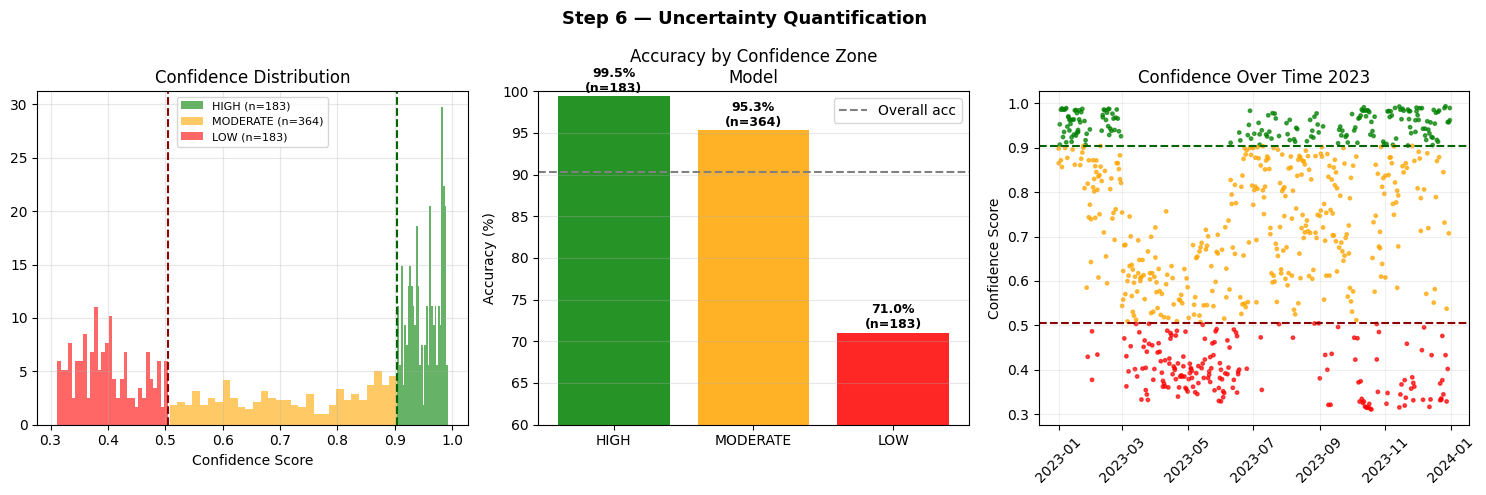

In [14]:
best_m   = results[best]['model']
proba_hi = results[best]['proba']   # P(SOILED)
proba_cl = 1 - proba_hi

# Entropy
p_mat   = np.column_stack([proba_cl, proba_hi])
p_mat   = np.clip(p_mat, 1e-10, 1)
entropy = -np.sum(p_mat*np.log(p_mat), axis=1) / np.log(2)
norm_ent= entropy / 1.0   # binary: max entropy = 1

# Inter-model disagreement
hi_stack = np.column_stack([
    results['Random Forest']['proba'],
    results['XGBoost']['proba'],
    results['LightGBM']['proba'],
])
disagreement = hi_stack.std(axis=1)

# Combined uncertainty
uncertainty = 0.6*norm_ent + 0.4*disagreement
confidence  = 1 - uncertainty

# Percentile zones
p75 = np.percentile(confidence, 75)
p25 = np.percentile(confidence, 25)

def zone(c):
    if c >= p75: return 'HIGH'
    if c >= p25: return 'MODERATE'
    return 'LOW'

zones = np.array([zone(c) for c in confidence])

res_unc = test_df[['time','city','risk_binary','dust_aod']]              .copy().reset_index(drop=True)
res_unc['pred']       = results[best]['pred']
res_unc['confidence'] = confidence
res_unc['uncertainty']= uncertainty
res_unc['zone']       = zones
res_unc['correct']    = (res_unc['pred']==res_unc['risk_binary'])
res_unc['p_soiled']   = proba_hi

print(f'Confidence percentiles: 25th={p25:.3f}, 75th={p75:.3f}')
print(f'\n{"Zone":<12} {"n":>6} {"Pct":>7} {"Accuracy":>10}')
print('-'*38)
for z in ['HIGH','MODERATE','LOW']:
    mask = zones == z
    n    = mask.sum()
    acc  = res_unc[mask]['correct'].mean()
    print(f' {z:<12} {n:>6} {n/len(zones)*100:>6.1f}%  {acc*100:>9.1f}%')

fig, axes = plt.subplots(1,3,figsize=(15,5))
fig.suptitle('Step 6 — Uncertainty Quantification',
             fontsize=13,fontweight='bold')

zone_colors = {'HIGH':'green','MODERATE':'orange','LOW':'red'}
for z,c in zone_colors.items():
    mask = zones==z
    axes[0].hist(confidence[mask],bins=30,color=c,alpha=0.6,
                 label=f'{z} (n={mask.sum()})',density=True)
axes[0].axvline(p75,color='darkgreen',linestyle='--',linewidth=1.5)
axes[0].axvline(p25,color='darkred',linestyle='--',linewidth=1.5)
axes[0].set_title('Confidence Distribution')
axes[0].set_xlabel('Confidence Score')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

zone_accs = [res_unc[zones==z]['correct'].mean()*100
             for z in ['HIGH','MODERATE','LOW']]
zone_ns   = [(zones==z).sum() for z in ['HIGH','MODERATE','LOW']]
bars = axes[1].bar(['HIGH','MODERATE','LOW'], zone_accs,
                   color=['green','orange','red'], alpha=0.85)
axes[1].axhline(y=results[best]['acc']*100,
                color='gray',linestyle='--',label='Overall acc')
axes[1].set_ylim(60,100)
axes[1].set_title('Accuracy by Confidence Zone\nModel')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(axis='y',alpha=0.3)
for bar,v,n in zip(bars,zone_accs,zone_ns):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.5,
                 f'{v:.1f}%\n(n={n})',ha='center',fontsize=9,fontweight='bold')

time_v = pd.to_datetime(res_unc['time'])
c_colors = [zone_colors[z] for z in zones]
axes[2].scatter(time_v, confidence, c=c_colors, s=6, alpha=0.7)
axes[2].axhline(p75,color='darkgreen',linestyle='--',linewidth=1.5)
axes[2].axhline(p25,color='darkred',linestyle='--',linewidth=1.5)
axes[2].set_title('Confidence Over Time 2023')
axes[2].set_ylabel('Confidence Score')
axes[2].tick_params(axis='x',rotation=45)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(BASE_PATH+'step6_uncertainty.png',dpi=150,bbox_inches='tight')
plt.show()
res_unc.to_csv(BASE_PATH+'predictions_with_uncertainty.csv',index=False)

## Step 7 — Seasonal Analysis (Khamaseen Validation)

Month      Acc     n  SOILED recall   Zone LOW%
--------------------------------------------------
 Jan     100.0%    62           N/A       1.6%
 Feb     100.0%    56           N/A       3.6%
 Mar      90.3%    62         42.9%      35.5%  KHAMASEEN
 Apr      83.3%    60         57.9%      58.3%  KHAMASEEN
 May      80.6%    62         81.8%      58.1%  KHAMASEEN
 Jun      70.0%    60         63.0%      40.0%
 Jul      96.8%    62        100.0%       4.8%
 Aug      90.3%    62         93.1%       6.5%
 Sep      93.3%    60         88.2%      10.0%
 Oct      88.7%    62         63.2%      32.3%
 Nov      96.7%    60         50.0%      23.3%
 Dec      95.2%    62         50.0%      25.8%


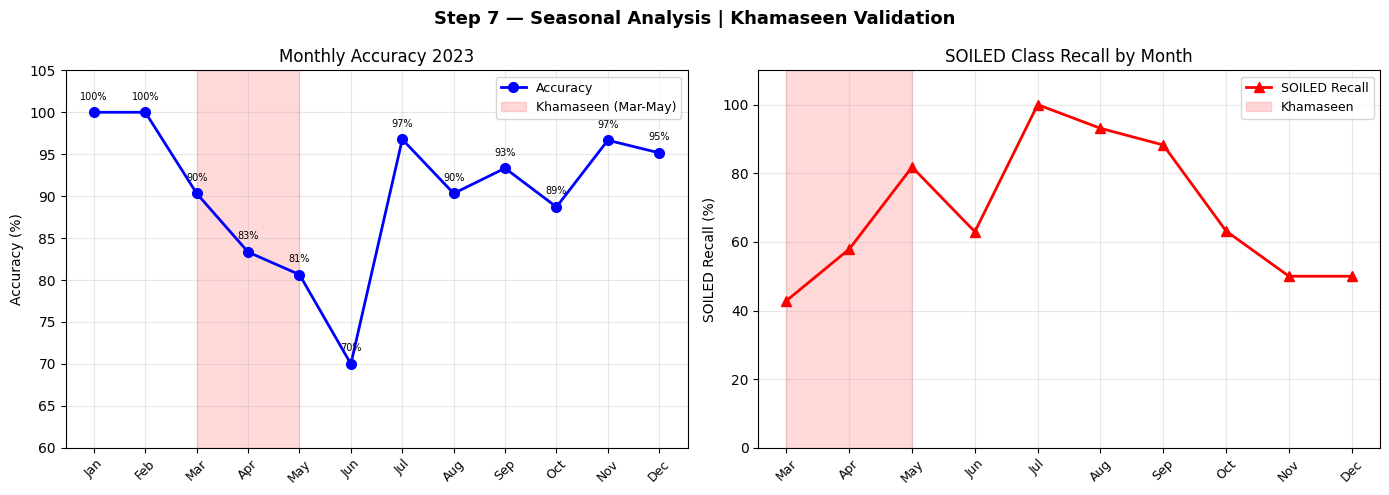

In [ ]:
res_unc['month'] = pd.to_datetime(res_unc['time']).dt.month
mnames = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
          7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

print(f'{"Month":<6}{"Acc":>8}{"n":>6}{"SOILED recall":>15}{"Zone LOW%":>12}')
print('-'*50)
monthly = []
for m in range(1,13):
    mask = res_unc['month']==m
    sub  = res_unc[mask]
    if len(sub)==0: continue
    acc  = sub['correct'].mean()*100
    n    = len(sub)
    s_mask = sub['risk_binary']=='SOILED'
    sr   = (sub[s_mask]['pred']=='SOILED').mean()*100 if s_mask.sum()>0 else np.nan
    low_pct = (sub['zone']=='LOW').mean()*100
    monthly.append({'month':m,'name':mnames[m],'acc':acc,
                    'n':n,'soiled_recall':sr,'low_zone_pct':low_pct})
    sr_s = f'{sr:.1f}%' if not np.isnan(sr) else 'N/A'
    kh   = '  KHAMASEEN' if m in [3,4,5] else ''
    print(f' {mnames[m]:<6}{acc:>7.1f}%{n:>6}{sr_s:>14}  {low_pct:>8.1f}%{kh}')

monthly_df = pd.DataFrame(monthly)

fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle('Step 7 — Seasonal Analysis | Khamaseen Validation',
             fontsize=13,fontweight='bold')

x = np.arange(len(monthly_df))
axes[0].plot(x, monthly_df['acc'], 'bo-',
             linewidth=2, markersize=7, label='Accuracy')
axes[0].axvspan(2,4,alpha=0.15,color='red',label='Khamaseen (Mar-May)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(monthly_df['name'],rotation=45,fontsize=9)
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(60,105)
axes[0].set_title('Monthly Accuracy 2023')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
for i,row in monthly_df.iterrows():
    axes[0].annotate(f"{row['acc']:.0f}%",
                     (list(x)[i],row['acc']+1.5),
                     ha='center',fontsize=7)

valid = monthly_df[monthly_df['soiled_recall'].notna()]
xv    = np.arange(len(valid))
axes[1].plot(xv, valid['soiled_recall'], 'r^-',
             linewidth=2, markersize=7, label='SOILED Recall')
axes[1].axvspan(
    list(valid['name']).index('Mar') if 'Mar' in list(valid['name']) else 2,
    list(valid['name']).index('May') if 'May' in list(valid['name']) else 4,
    alpha=0.15, color='red', label='Khamaseen')
axes[1].set_xticks(xv)
axes[1].set_xticklabels(valid['name'],rotation=45,fontsize=9)
axes[1].set_ylabel('SOILED Recall (%)'); axes[1].set_ylim(0,110)
axes[1].set_title('SOILED Class Recall by Month')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE_PATH+'step7_seasonal.png',dpi=150,bbox_inches='tight')
plt.show()

## Step 9 — Live Deployment (Gradio + Streamlit)

In [ ]:
!pip install gradio pyngrok -q
import joblib, pickle

best_model = results[best]['model']
joblib.dump(best_model, BASE_PATH+'rf_binary_model.pkl')
joblib.dump(imputer,    BASE_PATH+'imputer.pkl')
config = {
    'features'  : FEATURES,
    'boundary'  : K2_BOUNDARY,
    'model_name': best,
    'f1'        : results[best]['f1'],
    'auc'       : results[best]['auc'],
    'cities'    : {
        'Cairo': {'lat':30.06,'lon':31.24,'encoded':1},
        'Aswan': {'lat':24.09,'lon':32.90,'encoded':0},
    }
}
with open(BASE_PATH+'config.pkl','wb') as f:
    pickle.dump(config,f)
print(' Model artifacts saved')

 Model artifacts saved


In [ ]:
import gradio as gr
import requests

def fetch_and_predict(city_name, days=7):
    coords = config['cities'][city_name]
    url    = 'https://api.open-meteo.com/v1/forecast'
    params = {
        'latitude':coords['lat'],'longitude':coords['lon'],
        'daily':['temperature_2m_mean','precipitation_sum',
                 'wind_speed_10m_mean','wind_direction_10m_dominant',
                 'relative_humidity_2m_max','relative_humidity_2m_min',
                 'shortwave_radiation_sum','sunshine_duration'],
        'hourly':['pm10','pm2_5'],
        'forecast_days':days+2,'timezone':'auto','wind_speed_unit':'ms'
    }
    try:
        r = requests.get(url, params=params, timeout=15)
        data = r.json()
    except Exception as e:
        return None, str(e)

    daily = data['daily']
    n     = min(days, len(daily['time']))
    df    = pd.DataFrame()
    df['time']               = pd.to_datetime(daily['time'][:n])
    df['temperature_celsius']= daily.get('temperature_2m_mean',[25]*n)[:n]
    df['tp']                 = [p/1000 for p in
                                daily.get('precipitation_sum',[0]*n)[:n]]
    df['wind_speed']         = daily.get('wind_speed_10m_mean',[3]*n)[:n]
    df['wind_direction']     = daily.get('wind_direction_10m_dominant',[180]*n)[:n]
    rh_max = daily.get('relative_humidity_2m_max',[50]*n)[:n]
    rh_min = daily.get('relative_humidity_2m_min',[30]*n)[:n]
    df['relative_humidity']  = [(a+b)/2 for a,b in zip(rh_max,rh_min)]
    df['irradiance_direct']  = daily.get('shortwave_radiation_sum',[200]*n)[:n]
    df['sun_elevation']      = daily.get('sunshine_duration',[28800]*n)[:n]

    hourly = data.get('hourly',{})
    if hourly and 'time' in hourly:
        hdf = pd.DataFrame({
            'time':pd.to_datetime(hourly['time']),
            'pm10':hourly.get('pm10',[20]*len(hourly['time'])),
            'pm25':hourly.get('pm2_5',[10]*len(hourly['time'])),
        })
        hdf['date'] = hdf['time'].dt.date
        dd = hdf.groupby('date').agg({'pm10':'mean','pm25':'mean'}).reset_index()
        dd['date'] = pd.to_datetime(dd['date'])
        df['dk']   = df['time'].dt.date.astype(str)
        dd['dk']   = dd['date'].dt.date.astype(str)
        df = df.merge(dd[['dk','pm10','pm25']],on='dk',how='left')
        df['pm10_ugm3'] = df['pm10'].fillna(20)
        df['pm25_ugm3'] = df['pm25'].fillna(10)
        df = df.drop(columns=['pm10','pm25','dk'],errors='ignore')
    else:
        df['pm10_ugm3'] = 20.0
        df['pm25_ugm3'] = 10.0

    df['city_encoded']   = coords['encoded']
    df['month']          = df['time'].dt.month
    df['season_encoded'] = df['month'].apply(
        lambda m: 0 if m in[12,1,2] else 1 if m in[3,4,5]
        else 2 if m in[6,7,8] else 3)
    df['khamaseen_flag'] = df['month'].isin([3,4,5]).astype(int)
    for d in [3,7,14]:
        df[f'wind_speed_{d}d'] = df['wind_speed'].rolling(d,min_periods=1).mean()
    df['wind_speed_max_3d'] = df['wind_speed'].rolling(3,min_periods=1).max()
    df['humidity_7d_avg']   = df['relative_humidity'].rolling(7,min_periods=1).mean()
    df['precip_7d_sum']     = df['tp'].rolling(7,min_periods=1).sum()
    dsr,cnt = [],0
    for v in df['tp']:
        cnt = 0 if v>0.0001 else cnt+1; dsr.append(cnt)
    df['days_since_rain']   = dsr
    df['temp_variability']  = df['temperature_celsius'].rolling(7,min_periods=2).std().fillna(0)
    df['heatwave_flag']     = (df['temperature_celsius']>38).astype(int)
    df['dew_flag']          = (df['relative_humidity']>85).astype(int)
    df['irradiance_diffuse']   = df['irradiance_direct']*0.15
    df['irradiance_reflected'] = df['irradiance_direct']*0.05
    df['pv_power']             = df['irradiance_direct']*0.18
    return df.head(days), None

def run_forecast(city, days):
    days = int(days)
    df, err = fetch_and_predict(city, days)
    if err: return f'Error: {err}', None

    X   = pd.DataFrame(imputer.transform(df[FEATURES]), columns=FEATURES)
    enc = best_model.predict(X.values)
    prb = best_model.predict_proba(X.values)[:,1]
    df['pred']       = pd.Series(enc).map({0:'CLEAN',1:'SOILED'}).values
    df['confidence'] = np.maximum(prb, 1-prb)

    lines = [f'📍 {city} — {days}-Day Soiling Forecast',
             f'🗓  {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}',
             f'🤖 Binary RF | F1={results[best]["f1"]*100:.2f}% | '
             f'AUC={results[best]["auc"]:.4f}',
             '─'*55,
             f'{"Date":<12}{"Risk":<10}{"Conf":>6}{"Action":<20}'
             f'{"PM10":>6}{"Wind":>6}',
             '─'*55]
    clean_d, soiled_d = [], []
    for _,row in df.iterrows():
        r   = row['pred']
        act = '🚨 CLEAN TODAY' if r=='SOILED' else '✅ NO ACTION'
        em  = '🔴' if r=='SOILED' else '🟢'
        lines.append(f'{str(row["time"].date()):<12}'
                     f'{em}{r:<9}'
                     f'{row["confidence"]:>5.0%}'
                     f'{act:<20}'
                     f'{row["pm10_ugm3"]:>5.1f}'
                     f'{row["wind_speed"]:>5.1f}')
        (soiled_d if r=='SOILED' else clean_d).append(str(row['time'].date()))
    lines += ['─'*55,
              f'🔴 SOILED days: {len(soiled_d)}',
              f'🟢 CLEAN  days: {len(clean_d)}']
    if soiled_d:
        lines.append(f'🚨 CLEAN ON: {", ".join(soiled_d)}')

    # Plot
    import matplotlib; matplotlib.use('Agg')
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(13,5))
    fig.suptitle(f'{city} — {days}-Day Soiling Risk Forecast | '
                 f'{pd.Timestamp.now().strftime("%Y-%m-%d")}',
                 fontsize=12,fontweight='bold')
    x = range(len(df))
    colors = ['#d62728' if r=='SOILED' else '#2ca02c'
              for r in df['pred']]
    ax1.bar(x, df['confidence'], color=colors, alpha=0.85)
    ax1.set_xticks(list(x))
    ax1.set_xticklabels([str(d)[-5:] for d in df['time']],
                        rotation=45,fontsize=8)
    ax1.set_ylabel('Confidence'); ax1.set_ylim(0,1.1)
    ax1.set_title('Daily Risk (Red=SOILED, Green=CLEAN)')
    from matplotlib.patches import Patch
    ax1.legend(handles=[Patch(color='#d62728',label='SOILED'),
                        Patch(color='#2ca02c',label='CLEAN')])
    ax1.grid(axis='y',alpha=0.3)

    ax2.plot(df['time'],df['pm10_ugm3'],
             'b-o',linewidth=2,markersize=5,label='PM10 (μg/m³)')
    ax2b = ax2.twinx()
    ax2b.plot(df['time'],df['wind_speed'],
              'r--s',linewidth=2,markersize=5,label='Wind (m/s)')
    for _,row in df.iterrows():
        ax2.axvspan(row['time']-pd.Timedelta(hours=12),
                    row['time']+pd.Timedelta(hours=12),
                    alpha=0.1,
                    color='#d62728' if row['pred']=='SOILED' else '#2ca02c')
    ax2.set_title('PM10 & Wind (background=risk)')
    ax2.set_ylabel('PM10 (μg/m³)',color='blue')
    ax2b.set_ylabel('Wind (m/s)',color='red')
    ax2.tick_params(axis='x',rotation=45)
    ax2.grid(alpha=0.2)
    plt.tight_layout()
    return '\n'.join(lines), fig

with gr.Blocks(title='Solar Soiling Risk',theme=gr.themes.Soft()) as app:
    gr.Markdown('# ☀️ Solar Panel Soiling Risk System\n'
                '**Elsewedy Electric | Cairo & Aswan | Binary RF Model**')
    with gr.Row():
        with gr.Column(scale=1):
            city_in  = gr.Dropdown(['Cairo','Aswan'],value='Cairo',label='📍 City')
            days_in  = gr.Slider(3,14,value=7,step=1,label='📅 Forecast Days')
            btn      = gr.Button('🔍 Generate Forecast',variant='primary',size='lg')
            gr.Markdown(f'''
### Model Info
- Algorithm: {best}
- F1 Score: {results[best]["f1"]*100:.2f}%
- AUC-ROC: {results[best]["auc"]:.4f}
- Trained: 2019–2023
- Boundary: AOD = {K2_BOUNDARY:.4f}
### Decision
🔴 SOILED → Clean today
🟢 CLEAN  → No action
            ''')
        with gr.Column(scale=2):
            text_out  = gr.Textbox(label='Forecast',lines=20,show_copy_button=True)
    chart_out = gr.Plot(label='Risk Chart')
    btn.click(fn=run_forecast,inputs=[city_in,days_in],
              outputs=[text_out,chart_out])

print('\nLaunching app...')
app.launch(share=True, debug=False)


Launching app...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d5f7a4a25aa1cf0e51.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


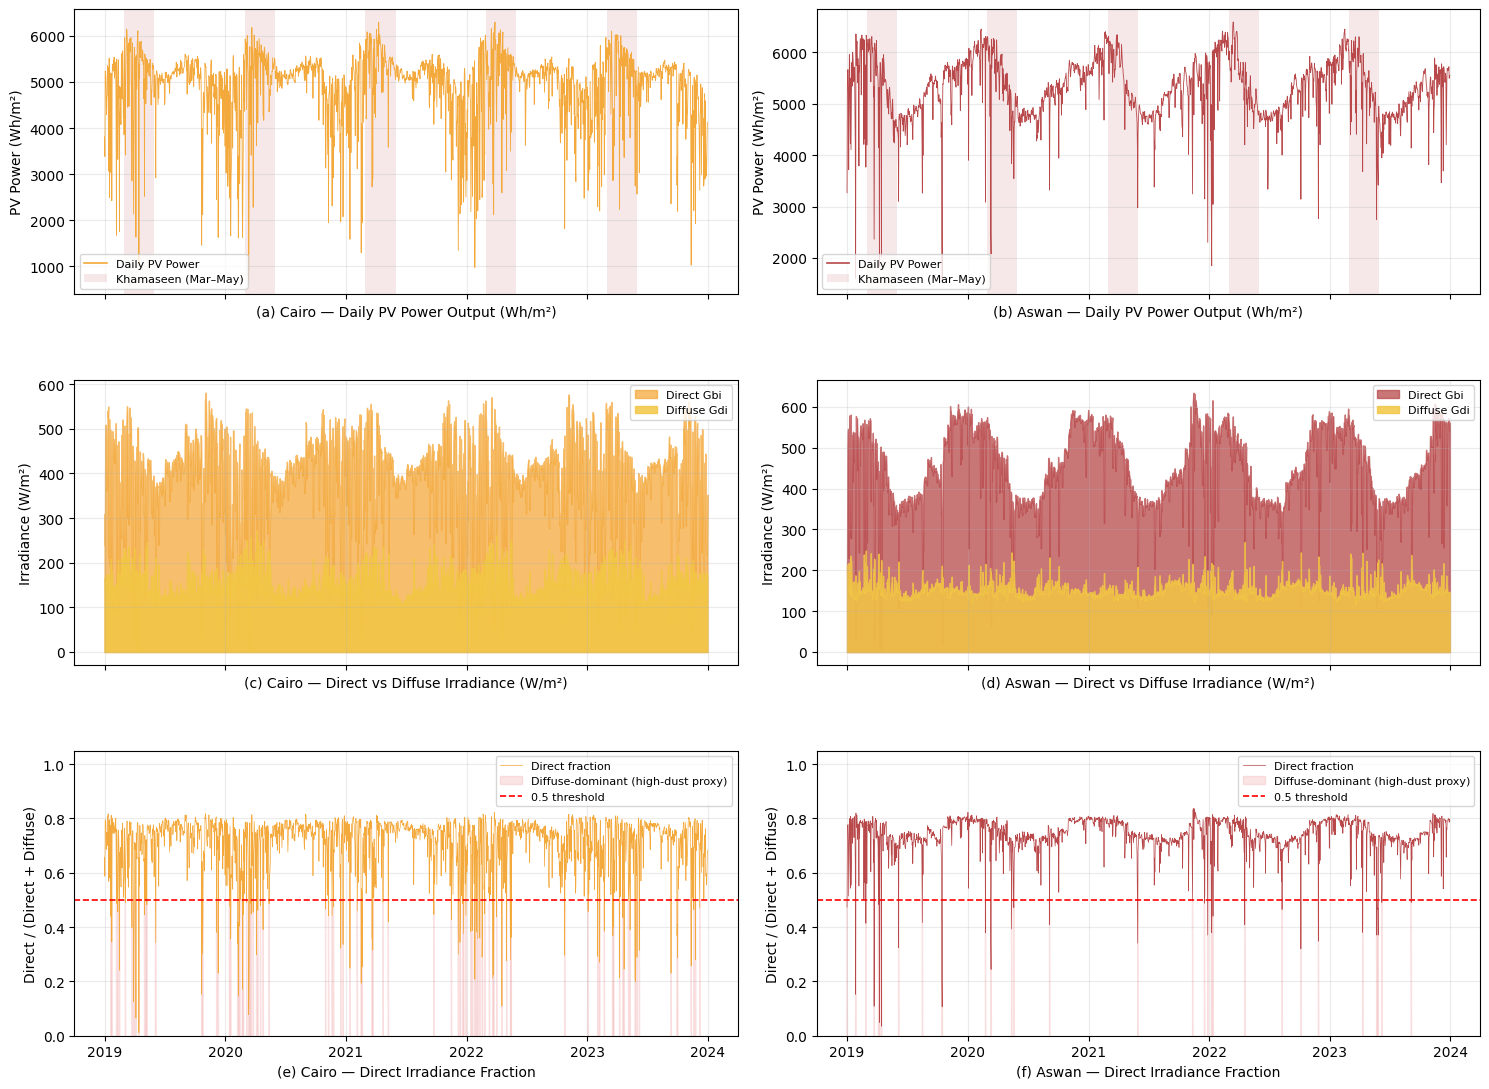

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Load ---
df = pd.read_csv(BASE_PATH + 'clean_data_2019_2023.csv')
df['time'] = pd.to_datetime(df['time'])

# Derived: direct fraction
df['direct_fraction'] = df['irradiance_direct'] / (
    df['irradiance_direct'] + df['irradiance_diffuse']
).replace(0, np.nan)

cairo = df[df['city'] == 'Cairo'].sort_values('time').reset_index(drop=True)
aswan = df[df['city'] == 'Aswan'].sort_values('time').reset_index(drop=True)

# Per-city color schemes
C_CAIRO = '#F4A93C'   # orange
C_ASWAN = '#B8484A'   # dark red
C_DIFF  = '#F2C744'   # yellow (diffuse)
KHAM    = '#B8484A'   # khamaseen shade

YEARS = range(2019, 2024)

def shade_khamaseen(ax, color, alpha=0.12):
    for y in YEARS:
        ax.axvspan(pd.Timestamp(f'{y}-03-01'),
                   pd.Timestamp(f'{y}-05-31'),
                   color=color, alpha=alpha, lw=0)

# --- Figure ---
fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)

# (a) Cairo PV
ax = axes[0,0]
ax.plot(cairo['time'], cairo['pv_power'], color=C_CAIRO, lw=0.6, label='Daily PV Power')
shade_khamaseen(ax, KHAM)
ax.set_ylabel('PV Power (Wh/m²)')
ax.legend(loc='lower left', fontsize=8,
          handles=[plt.Line2D([],[],color=C_CAIRO,lw=1.2,label='Daily PV Power'),
                   plt.Rectangle((0,0),1,1,fc=KHAM,alpha=0.12,label='Khamaseen (Mar–May)')])
ax.grid(alpha=0.25)
ax.set_title('(a) Cairo — Daily PV Power Output (Wh/m²)', y=-0.30, fontsize=10)

# (b) Aswan PV
ax = axes[0,1]
ax.plot(aswan['time'], aswan['pv_power'], color=C_ASWAN, lw=0.6, label='Daily PV Power')
shade_khamaseen(ax, KHAM)
ax.set_ylabel('PV Power (Wh/m²)')
ax.legend(loc='lower left', fontsize=8,
          handles=[plt.Line2D([],[],color=C_ASWAN,lw=1.2,label='Daily PV Power'),
                   plt.Rectangle((0,0),1,1,fc=KHAM,alpha=0.12,label='Khamaseen (Mar–May)')])
ax.grid(alpha=0.25)
ax.set_title('(b) Aswan — Daily PV Power Output (Wh/m²)', y=-0.30, fontsize=10)

# (c) Cairo Direct vs Diffuse
ax = axes[1,0]
ax.fill_between(cairo['time'], 0, cairo['irradiance_direct'],
                color=C_CAIRO, alpha=0.75, label='Direct Gbi')
ax.fill_between(cairo['time'], 0, cairo['irradiance_diffuse'],
                color=C_DIFF, alpha=0.85, label='Diffuse Gdi')
ax.set_ylabel('Irradiance (W/m²)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.25)
ax.set_title('(c) Cairo — Direct vs Diffuse Irradiance (W/m²)', y=-0.30, fontsize=10)

# (d) Aswan Direct vs Diffuse
ax = axes[1,1]
ax.fill_between(aswan['time'], 0, aswan['irradiance_direct'],
                color=C_ASWAN, alpha=0.75, label='Direct Gbi')
ax.fill_between(aswan['time'], 0, aswan['irradiance_diffuse'],
                color=C_DIFF, alpha=0.85, label='Diffuse Gdi')
ax.set_ylabel('Irradiance (W/m²)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.25)
ax.set_title('(d) Aswan — Direct vs Diffuse Irradiance (W/m²)', y=-0.30, fontsize=10)

# (e) Cairo Direct Fraction
ax = axes[2,0]
ax.plot(cairo['time'], cairo['direct_fraction'], color=C_CAIRO, lw=0.5,
        label='Direct fraction')
ax.fill_between(cairo['time'], 0, 0.5,
                where=cairo['direct_fraction'] < 0.5,
                color='#F2A6A8', alpha=0.30,
                label='Diffuse-dominant (high-dust proxy)',
                interpolate=True)
ax.axhline(0.5, color='red', ls='--', lw=1.2, label='0.5 threshold')
ax.set_ylim(0, 1.05); ax.set_ylabel('Direct / (Direct + Diffuse)')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.25)
ax.set_title('(e) Cairo — Direct Irradiance Fraction', y=-0.34, fontsize=10)

# (f) Aswan Direct Fraction
ax = axes[2,1]
ax.plot(aswan['time'], aswan['direct_fraction'], color=C_ASWAN, lw=0.5,
        label='Direct fraction')
ax.fill_between(aswan['time'], 0, 0.5,
                where=aswan['direct_fraction'] < 0.5,
                color='#F2A6A8', alpha=0.30,
                label='Diffuse-dominant (high-dust proxy)',
                interpolate=True)
ax.axhline(0.5, color='red', ls='--', lw=1.2, label='0.5 threshold')
ax.set_ylim(0, 1.05); ax.set_ylabel('Direct / (Direct + Diffuse)')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.25)
ax.set_title('(f) Aswan — Direct Irradiance Fraction', y=-0.34, fontsize=10)

# Titles directly under each panel — minimal gap
for ax, label in zip(axes.flat, [
    '(a) Cairo — Daily PV Power Output (Wh/m²)',
    '(b) Aswan — Daily PV Power Output (Wh/m²)',
    '(c) Cairo — Direct vs Diffuse Irradiance (W/m²)',
    '(d) Aswan — Direct vs Diffuse Irradiance (W/m²)',
    '(e) Cairo — Direct Irradiance Fraction',
    '(f) Aswan — Direct Irradiance Fraction',
]):
    ax.set_title('')                              # clear any old title
    ax.set_xlabel(label, fontsize=10, labelpad=4) # put caption AS the xlabel

# Keep year ticks on bottom row, hide tick LABELS on rows 1 & 2 (titles use xlabel slot)
for ax in axes[:2, :].flat:
    ax.tick_params(labelbottom=False)
for ax in axes[2, :]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.subplots_adjust(hspace=0.30)
plt.savefig(BASE_PATH + 'fig1_pvgis_timeseries.png',
            dpi=150, bbox_inches='tight')
plt.show()

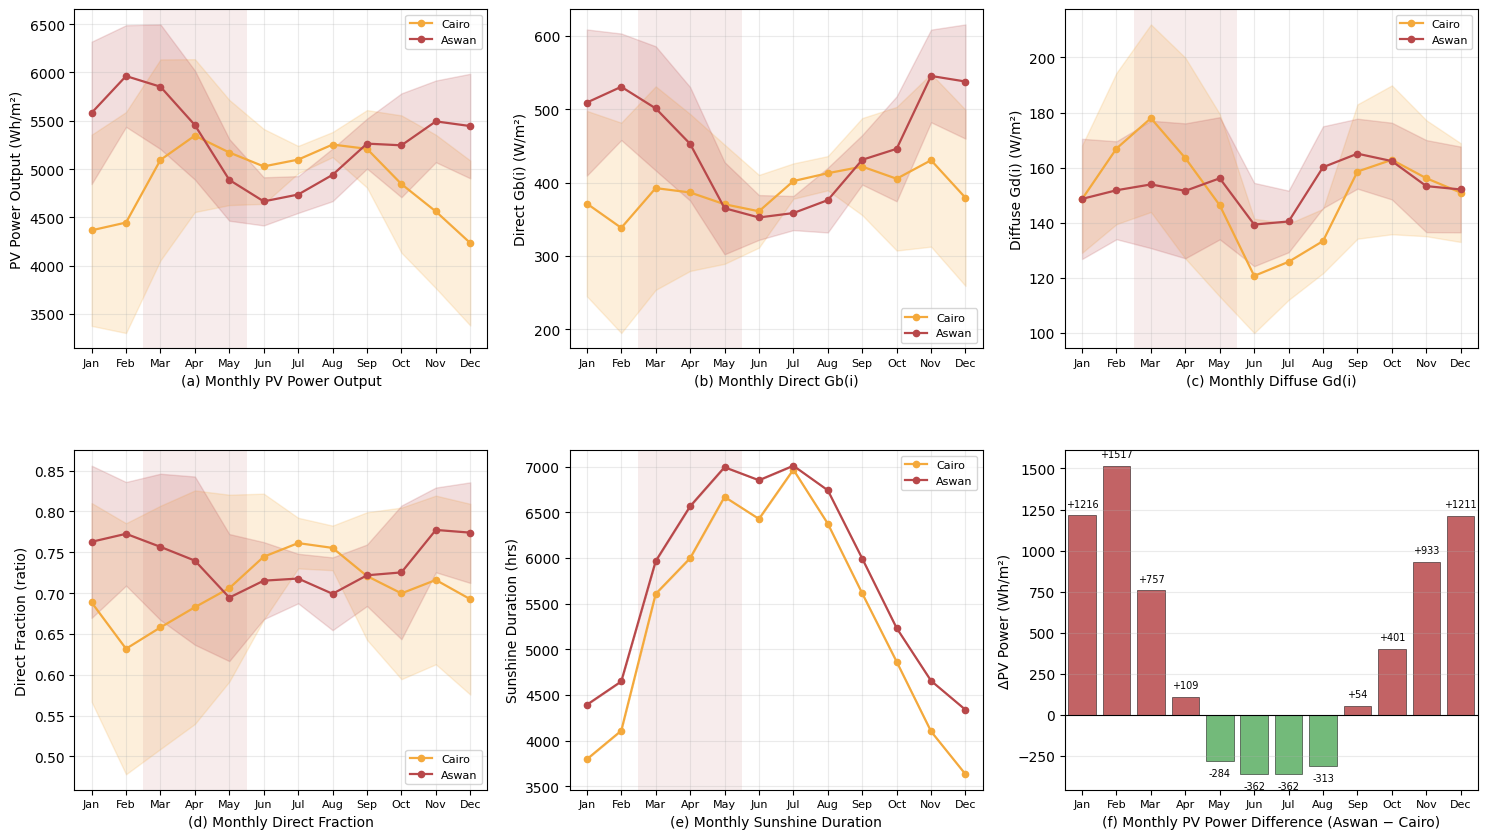

Saved: fig2_pvgis_monthly_climatology.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load (re-use df if already in memory) ---
df = pd.read_csv(BASE_PATH + 'clean_data_2019_2023.csv')
df['time'] = pd.to_datetime(df['time'])
df['month'] = df['time'].dt.month
df['direct_fraction'] = df['irradiance_direct'] / (
    df['irradiance_direct'] + df['irradiance_diffuse']
).replace(0, np.nan)

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

C_CAIRO = '#F4A93C'
C_ASWAN = '#B8484A'
KHAM_X  = [3, 4, 5]
KHAM_C  = '#B8484A'

def monthly_stats(d, col, how='mean'):
    g = d.groupby('month')[col]
    return (g.sum() if how == 'sum' else g.mean()), g.std()

def shade_khamaseen(ax):
    for m in KHAM_X:
        ax.axvspan(m - 0.5, m + 0.5, color=KHAM_C, alpha=0.10, lw=0)

def plot_band(ax, mean, std, color, label):
    ax.plot(range(1,13), mean.values, '-o', color=color, lw=1.6,
            ms=4.5, label=label)
    ax.fill_between(range(1,13),
                    mean.values - std.values,
                    mean.values + std.values,
                    color=color, alpha=0.18)

cairo = df[df['city'] == 'Cairo']
aswan = df[df['city'] == 'Aswan']

# --- Figure ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))

# (a) PV Power
ax = axes[0,0]; shade_khamaseen(ax)
plot_band(ax, *monthly_stats(cairo,'pv_power'), C_CAIRO, 'Cairo')
plot_band(ax, *monthly_stats(aswan,'pv_power'), C_ASWAN, 'Aswan')
ax.set_ylabel('PV Power Output (Wh/m²)'); ax.legend(fontsize=8); ax.grid(alpha=0.25)

# (b) Direct
ax = axes[0,1]; shade_khamaseen(ax)
plot_band(ax, *monthly_stats(cairo,'irradiance_direct'), C_CAIRO, 'Cairo')
plot_band(ax, *monthly_stats(aswan,'irradiance_direct'), C_ASWAN, 'Aswan')
ax.set_ylabel('Direct Gb(i) (W/m²)'); ax.legend(fontsize=8); ax.grid(alpha=0.25)

# (c) Diffuse
ax = axes[0,2]; shade_khamaseen(ax)
plot_band(ax, *monthly_stats(cairo,'irradiance_diffuse'), C_CAIRO, 'Cairo')
plot_band(ax, *monthly_stats(aswan,'irradiance_diffuse'), C_ASWAN, 'Aswan')
ax.set_ylabel('Diffuse Gd(i) (W/m²)'); ax.legend(fontsize=8); ax.grid(alpha=0.25)

# (d) Direct fraction
ax = axes[1,0]; shade_khamaseen(ax)
plot_band(ax, *monthly_stats(cairo,'direct_fraction'), C_CAIRO, 'Cairo')
plot_band(ax, *monthly_stats(aswan,'direct_fraction'), C_ASWAN, 'Aswan')
ax.set_ylabel('Direct Fraction (ratio)'); ax.legend(fontsize=8); ax.grid(alpha=0.25)

# (e) Sunshine duration (monthly sum of sun_elevation)
ax = axes[1,1]; shade_khamaseen(ax)
plot_band(ax, *monthly_stats(cairo,'sun_elevation', how='sum'), C_CAIRO, 'Cairo')
plot_band(ax, *monthly_stats(aswan,'sun_elevation', how='sum'), C_ASWAN, 'Aswan')
ax.set_ylabel('Sunshine Duration (hrs)'); ax.legend(fontsize=8); ax.grid(alpha=0.25)

# (f) ΔPV Power (Aswan − Cairo)
ax = axes[1,2]
diff = (aswan.groupby('month')['pv_power'].mean()
        - cairo.groupby('month')['pv_power'].mean())
colors_bar = [C_ASWAN if v >= 0 else '#5BAE63' for v in diff.values]
bars = ax.bar(range(1,13), diff.values, color=colors_bar,
              edgecolor='black', lw=0.4, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
for b, v in zip(bars, diff.values):
    ax.text(b.get_x() + b.get_width()/2,
            v + (40 if v >= 0 else -40),
            f'{v:+.0f}',
            ha='center', va='bottom' if v >= 0 else 'top', fontsize=7)
ax.set_ylabel('ΔPV Power (Wh/m²)'); ax.grid(alpha=0.25, axis='y')

# Month labels + below-panel captions
labels = [
    '(a) Monthly PV Power Output',
    '(b) Monthly Direct Gb(i)',
    '(c) Monthly Diffuse Gd(i)',
    '(d) Monthly Direct Fraction',
    '(e) Monthly Sunshine Duration',
    '(f) Monthly PV Power Difference (Aswan − Cairo)',
]
for ax, cap in zip(axes.flat, labels):
    ax.set_title('')
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(MONTHS, fontsize=8)
    ax.set_xlabel(cap, fontsize=10, labelpad=4)
    ax.set_xlim(0.5, 12.5)

plt.tight_layout()
plt.subplots_adjust(hspace=0.30)
plt.savefig(BASE_PATH + 'fig2_pvgis_monthly_climatology.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_pvgis_monthly_climatology.png')

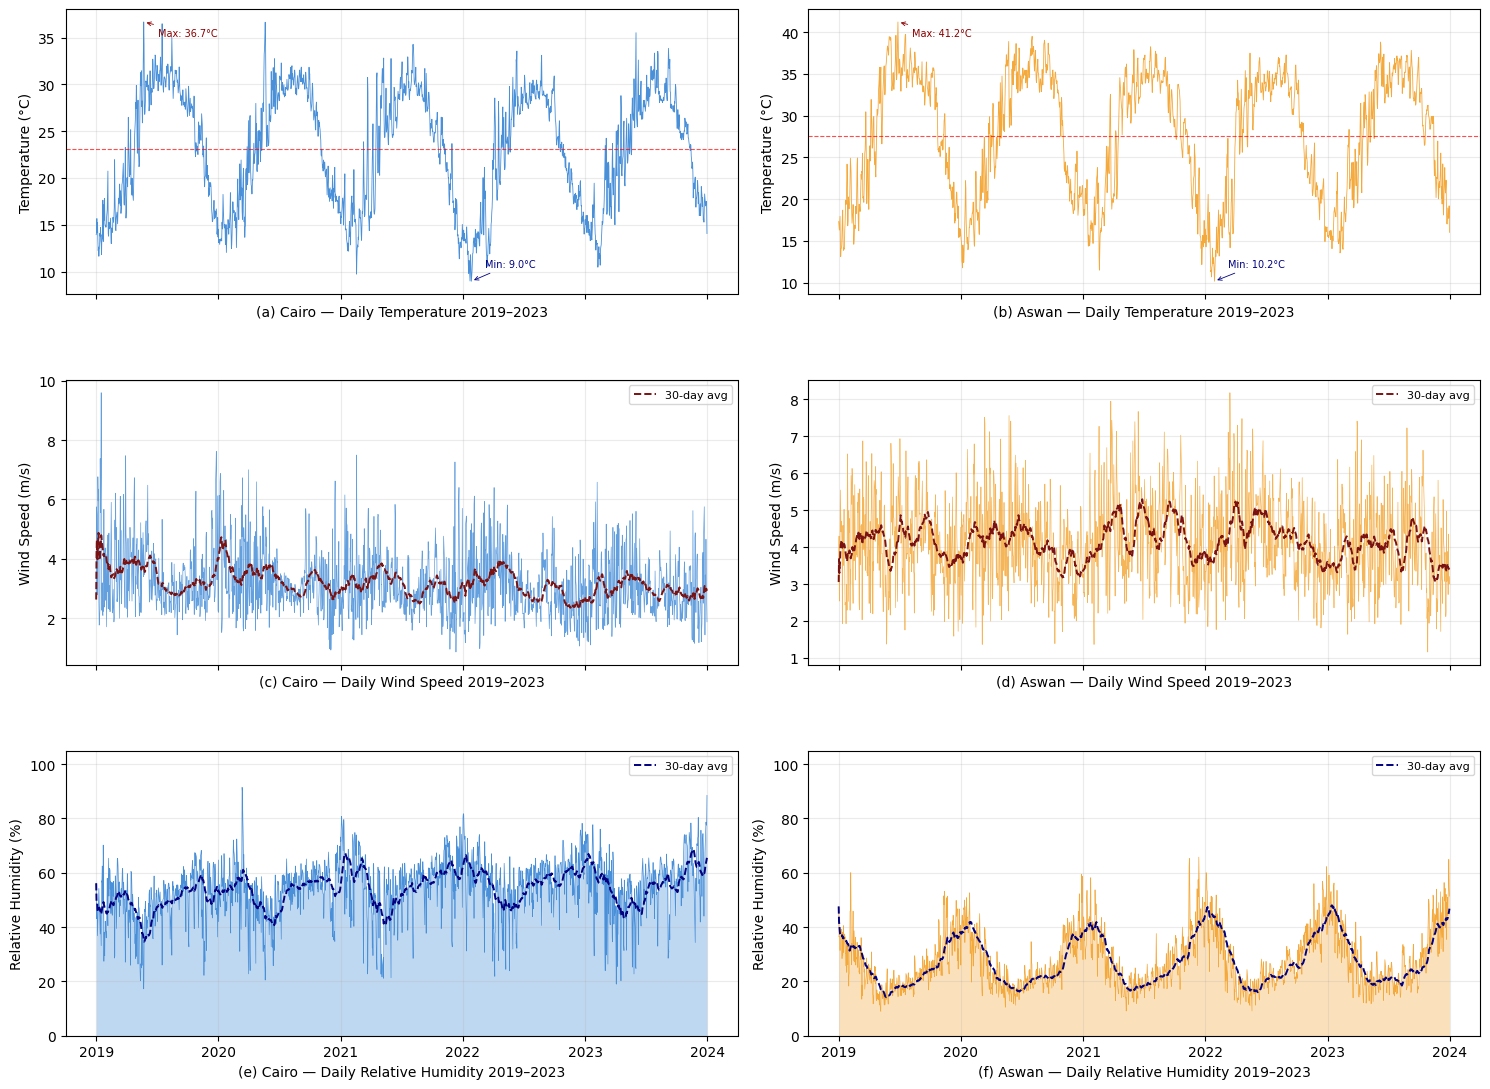

Saved: fig3_era5_daily_timeseries.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(BASE_PATH + 'clean_data_2019_2023.csv')
df['time'] = pd.to_datetime(df['time'])

cairo = df[df['city'] == 'Cairo'].sort_values('time').reset_index(drop=True)
aswan = df[df['city'] == 'Aswan'].sort_values('time').reset_index(drop=True)

C_CAIRO = '#4A90D9'   # blue
C_ASWAN = '#F4A93C'   # orange

# --- Figure ---
fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)

def plot_temp(ax, d, color, label):
    ax.plot(d['time'], d['temperature_celsius'], color=color, lw=0.6)
    mean_t = d['temperature_celsius'].mean()
    ax.axhline(mean_t, color='red', ls='--', lw=0.8, alpha=0.7)
    # Annotate annual min/max
    idx_max = d['temperature_celsius'].idxmax()
    idx_min = d['temperature_celsius'].idxmin()
    ax.annotate(f"Max: {d.loc[idx_max,'temperature_celsius']:.1f}°C",
                xy=(d.loc[idx_max,'time'], d.loc[idx_max,'temperature_celsius']),
                xytext=(10, -10), textcoords='offset points',
                fontsize=7, color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=0.6))
    ax.annotate(f"Min: {d.loc[idx_min,'temperature_celsius']:.1f}°C",
                xy=(d.loc[idx_min,'time'], d.loc[idx_min,'temperature_celsius']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=7, color='navy',
                arrowprops=dict(arrowstyle='->', color='navy', lw=0.6))
    ax.set_ylabel('Temperature (°C)')

def plot_wind(ax, d, color):
    ax.plot(d['time'], d['wind_speed'], color=color, lw=0.5, alpha=0.85)
    roll = d['wind_speed'].rolling(30, min_periods=1).mean()
    ax.plot(d['time'], roll, color='#7A1212', ls='--', lw=1.4, label='30-day avg')
    ax.set_ylabel('Wind Speed (m/s)')
    ax.legend(loc='upper right', fontsize=8)

def plot_humidity(ax, d, color):
    ax.fill_between(d['time'], 0, d['relative_humidity'],
                    color=color, alpha=0.35, lw=0)
    ax.plot(d['time'], d['relative_humidity'], color=color, lw=0.5)
    roll = d['relative_humidity'].rolling(30, min_periods=1).mean()
    ax.plot(d['time'], roll, color='navy', ls='--', lw=1.4, label='30-day avg')
    ax.set_ylabel('Relative Humidity (%)')
    ax.set_ylim(0, 105)
    ax.legend(loc='upper right', fontsize=8)

# (a) (b) Temperature
plot_temp(axes[0,0], cairo, C_CAIRO, 'Cairo')
plot_temp(axes[0,1], aswan, C_ASWAN, 'Aswan')
# (c) (d) Wind
plot_wind(axes[1,0], cairo, C_CAIRO)
plot_wind(axes[1,1], aswan, C_ASWAN)
# (e) (f) Humidity
plot_humidity(axes[2,0], cairo, C_CAIRO)
plot_humidity(axes[2,1], aswan, C_ASWAN)

for ax in axes.flat:
    ax.grid(alpha=0.25)

# X-axis year ticks on bottom row, hide on rows 1 & 2
for ax in axes[:2, :].flat:
    ax.tick_params(labelbottom=False)
for ax in axes[2, :]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

labels = [
    '(a) Cairo — Daily Temperature 2019–2023',
    '(b) Aswan — Daily Temperature 2019–2023',
    '(c) Cairo — Daily Wind Speed 2019–2023',
    '(d) Aswan — Daily Wind Speed 2019–2023',
    '(e) Cairo — Daily Relative Humidity 2019–2023',
    '(f) Aswan — Daily Relative Humidity 2019–2023',
]
for ax, cap in zip(axes.flat, labels):
    ax.set_title('')
    ax.set_xlabel(cap, fontsize=10, labelpad=4)

plt.tight_layout()
plt.subplots_adjust(hspace=0.30)
plt.savefig(BASE_PATH + 'fig3_era5_daily_timeseries.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_era5_daily_timeseries.png')

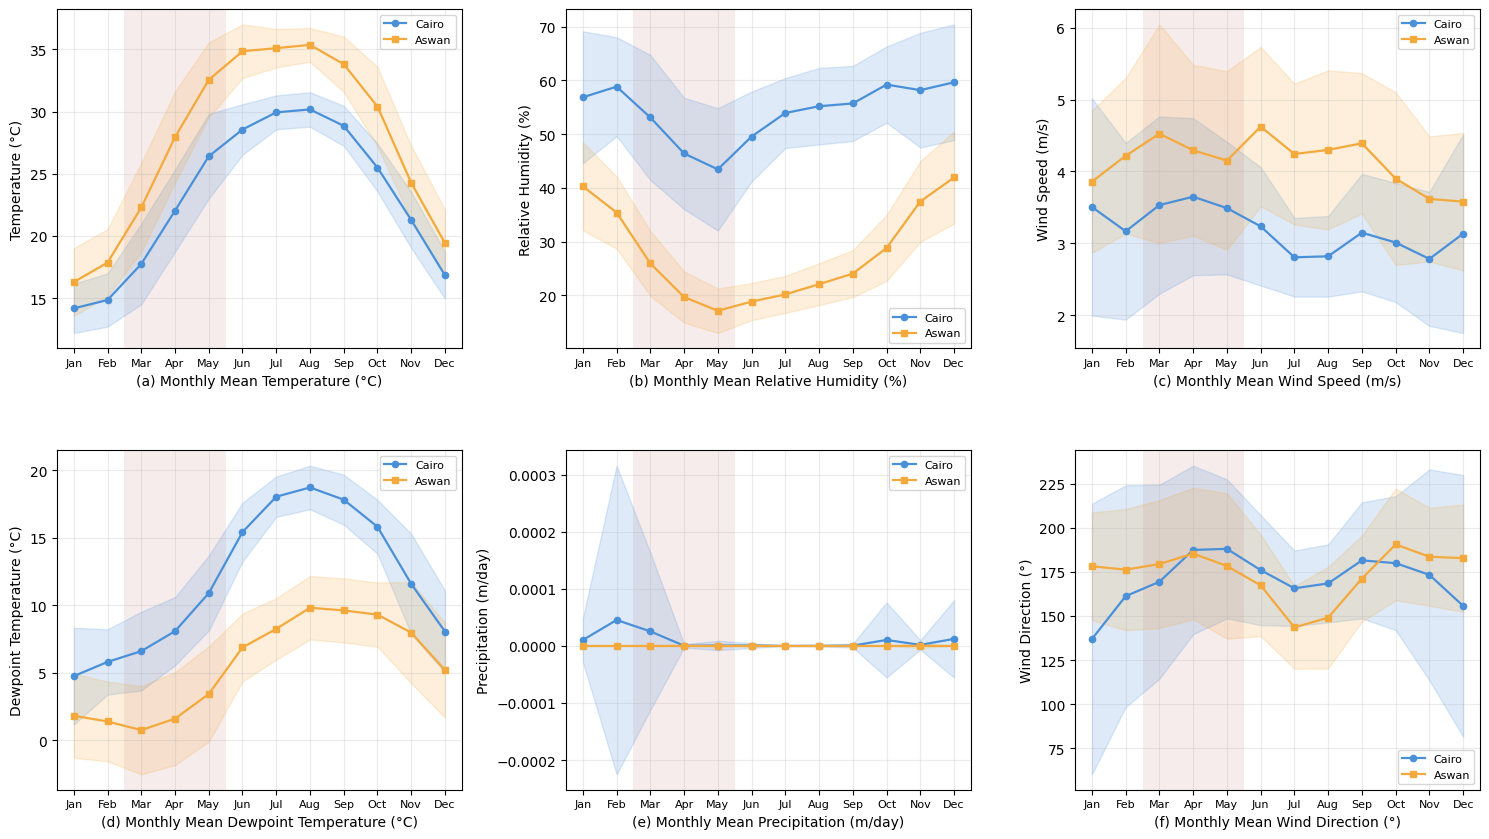

Saved: fig4_era5_monthly_climatology.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(BASE_PATH + 'clean_data_2019_2023.csv')
df['time']  = pd.to_datetime(df['time'])
df['month'] = df['time'].dt.month

cairo = df[df['city'] == 'Cairo']
aswan = df[df['city'] == 'Aswan']

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

C_CAIRO = '#4A90D9'   # blue (match Fig 3)
C_ASWAN = '#F4A93C'   # orange
KHAM_X  = [3, 4, 5]
KHAM_C  = '#B8484A'

def monthly_stats(d, col, how='mean'):
    g = d.groupby('month')[col]
    return (g.sum() if how == 'sum' else g.mean()), g.std()

def shade_khamaseen(ax):
    for m in KHAM_X:
        ax.axvspan(m - 0.5, m + 0.5, color=KHAM_C, alpha=0.10, lw=0)

def plot_band(ax, mean, std, color, label, marker='o'):
    ax.plot(range(1, 13), mean.values, '-', marker=marker, color=color,
            lw=1.6, ms=4.5, label=label)
    ax.fill_between(range(1, 13),
                    mean.values - std.values,
                    mean.values + std.values,
                    color=color, alpha=0.18)

# --- Figure ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))

# (a) Temperature
ax = axes[0,0]; shade_khamaseen(ax)
plot_band(ax, *monthly_stats(cairo,'temperature_celsius'), C_CAIRO, 'Cairo')
plot_band(ax, *monthly_stats(aswan,'temperature_celsius'), C_ASWAN, 'Aswan', marker='s')
ax.set_ylabel('Temperature (°C)'); ax.legend(fontsize=8)

# (b) Relative Humidity
ax = axes[0,1]; shade_khamaseen(ax)
plot_band(ax, *monthly_stats(cairo,'relative_humidity'), C_CAIRO, 'Cairo')
plot_band(ax, *monthly_stats(aswan,'relative_humidity'), C_ASWAN, 'Aswan', marker='s')
ax.set_ylabel('Relative Humidity (%)'); ax.legend(fontsize=8)

# (c) Wind Speed
ax = axes[0,2]; shade_khamaseen(ax)
plot_band(ax, *monthly_stats(cairo,'wind_speed'), C_CAIRO, 'Cairo')
plot_band(ax, *monthly_stats(aswan,'wind_speed'), C_ASWAN, 'Aswan', marker='s')
ax.set_ylabel('Wind Speed (m/s)'); ax.legend(fontsize=8)

# (d) Dewpoint
ax = axes[1,0]; shade_khamaseen(ax)
plot_band(ax, *monthly_stats(cairo,'dewpoint_celsius'), C_CAIRO, 'Cairo')
plot_band(ax, *monthly_stats(aswan,'dewpoint_celsius'), C_ASWAN, 'Aswan', marker='s')
ax.set_ylabel('Dewpoint Temperature (°C)'); ax.legend(fontsize=8)

# (e) Precipitation
ax = axes[1,1]; shade_khamaseen(ax)
plot_band(ax, *monthly_stats(cairo,'tp'), C_CAIRO, 'Cairo')
plot_band(ax, *monthly_stats(aswan,'tp'), C_ASWAN, 'Aswan', marker='s')
ax.set_ylabel('Precipitation (m/day)'); ax.legend(fontsize=8)

# (f) Wind Direction
ax = axes[1,2]; shade_khamaseen(ax)
plot_band(ax, *monthly_stats(cairo,'wind_direction'), C_CAIRO, 'Cairo')
plot_band(ax, *monthly_stats(aswan,'wind_direction'), C_ASWAN, 'Aswan', marker='s')
ax.set_ylabel('Wind Direction (°)'); ax.legend(fontsize=8)

# Apply month ticks, grid, and below-panel captions
labels = [
    '(a) Monthly Mean Temperature (°C)',
    '(b) Monthly Mean Relative Humidity (%)',
    '(c) Monthly Mean Wind Speed (m/s)',
    '(d) Monthly Mean Dewpoint Temperature (°C)',
    '(e) Monthly Mean Precipitation (m/day)',
    '(f) Monthly Mean Wind Direction (°)',
]
for ax, cap in zip(axes.flat, labels):
    ax.set_title('')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTHS, fontsize=8)
    ax.set_xlim(0.5, 12.5)
    ax.grid(alpha=0.25)
    ax.set_xlabel(cap, fontsize=10, labelpad=4)

plt.tight_layout()
plt.subplots_adjust(hspace=0.30)
plt.savefig(BASE_PATH + 'fig4_era5_monthly_climatology.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_era5_monthly_climatology.png')

In [ ]:
print(df.columns.tolist())

['time', 'pv_power', 'irradiance_direct', 'irradiance_diffuse', 'irradiance_reflected', 'sun_elevation', 'city', 'tp', 'wind_speed', 'wind_direction', 'relative_humidity', 'temperature_celsius', 'u10', 'v10', 'dust_aod', 'pm25_ugm3', 'pm10_ugm3', 'month']


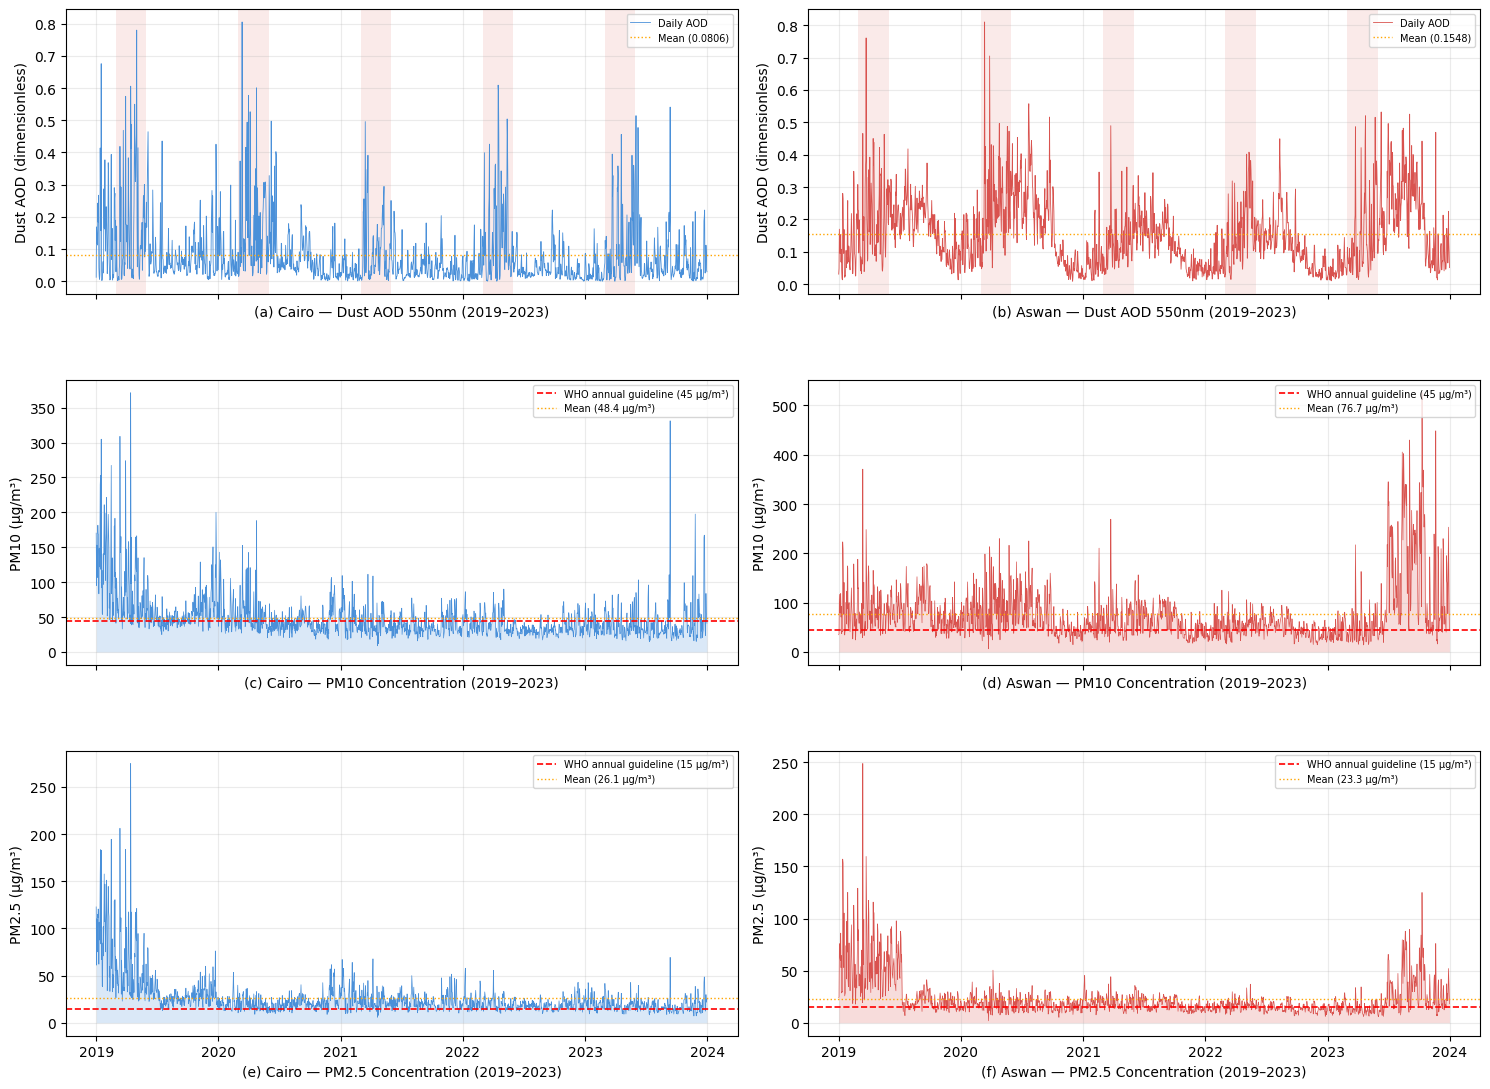

Saved: fig5_cams_daily_timeseries.png


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(BASE_PATH + 'clean_data_2019_2023.csv')
df['time'] = pd.to_datetime(df['time'])
cairo = df[df['city'] == 'Cairo'].sort_values('time').reset_index(drop=True)
aswan = df[df['city'] == 'Aswan'].sort_values('time').reset_index(drop=True)

C_CAIRO = '#4A90D9'   # blue
C_ASWAN = '#D9534F'   # red
KHAM_C  = '#D9534F'
K2_BOUNDARY = 0.1666
WHO_PM10  = 45     # μg/m³ annual guideline
WHO_PM25  = 15     # μg/m³ annual guideline
YEARS = range(2019, 2024)

def shade_khamaseen(ax):
    for y in YEARS:
        ax.axvspan(pd.Timestamp(f'{y}-03-01'),
                   pd.Timestamp(f'{y}-05-31'),
                   color=KHAM_C, alpha=0.12, lw=0)

# --- Figure ---
fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)

# (a) (b) Dust AOD — without K=2 boundary
for ax, d, color in zip(axes[0,:], [cairo, aswan], [C_CAIRO, C_ASWAN]):
    shade_khamaseen(ax)
    ax.plot(d['time'], d['dust_aod'], color=color, lw=0.6, label='Daily AOD')
    m = d['dust_aod'].mean()
    ax.axhline(m, color='orange', ls=':', lw=1.0,
               label=f'Mean ({m:.4f})')
    ax.set_ylabel('Dust AOD (dimensionless)')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(alpha=0.25)

# (c) (d) PM10
for col, (ax, d, color) in enumerate(zip(
        axes[1,:], [cairo, aswan], [C_CAIRO, C_ASWAN])):
    ax.fill_between(d['time'], 0, d['pm10_ugm3'], color=color, alpha=0.20, lw=0)
    ax.plot(d['time'], d['pm10_ugm3'], color=color, lw=0.5)
    ax.axhline(WHO_PM10, color='red', ls='--', lw=1.2,
               label=f'WHO annual guideline ({WHO_PM10} μg/m³)')
    m = d['pm10_ugm3'].mean()
    ax.axhline(m, color='orange', ls=':', lw=1.0,
               label=f'Mean ({m:.1f} μg/m³)')
    ax.set_ylabel('PM10 (μg/m³)')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(alpha=0.25)

# (e) (f) PM2.5
for col, (ax, d, color) in enumerate(zip(
        axes[2,:], [cairo, aswan], [C_CAIRO, C_ASWAN])):
    ax.fill_between(d['time'], 0, d['pm25_ugm3'], color=color, alpha=0.20, lw=0)
    ax.plot(d['time'], d['pm25_ugm3'], color=color, lw=0.5)
    ax.axhline(WHO_PM25, color='red', ls='--', lw=1.2,
               label=f'WHO annual guideline ({WHO_PM25} μg/m³)')
    m = d['pm25_ugm3'].mean()
    ax.axhline(m, color='orange', ls=':', lw=1.0,
               label=f'Mean ({m:.1f} μg/m³)')
    ax.set_ylabel('PM2.5 (μg/m³)')
    ax.legend(loc='upper right', fontsize=7)
    ax.grid(alpha=0.25)

# X-axis year ticks only on bottom row
for ax in axes[:2, :].flat:
    ax.tick_params(labelbottom=False)
for ax in axes[2, :]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Below-panel captions
labels = [
    '(a) Cairo — Dust AOD 550nm (2019–2023)',
    '(b) Aswan — Dust AOD 550nm (2019–2023)',
    '(c) Cairo — PM10 Concentration (2019–2023)',
    '(d) Aswan — PM10 Concentration (2019–2023)',
    '(e) Cairo — PM2.5 Concentration (2019–2023)',
    '(f) Aswan — PM2.5 Concentration (2019–2023)',
]
for ax, cap in zip(axes.flat, labels):
    ax.set_title('')
    ax.set_xlabel(cap, fontsize=10, labelpad=4)

plt.tight_layout()
plt.subplots_adjust(hspace=0.30)
plt.savefig(BASE_PATH + 'fig5_cams_daily_timeseries.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_cams_daily_timeseries.png')

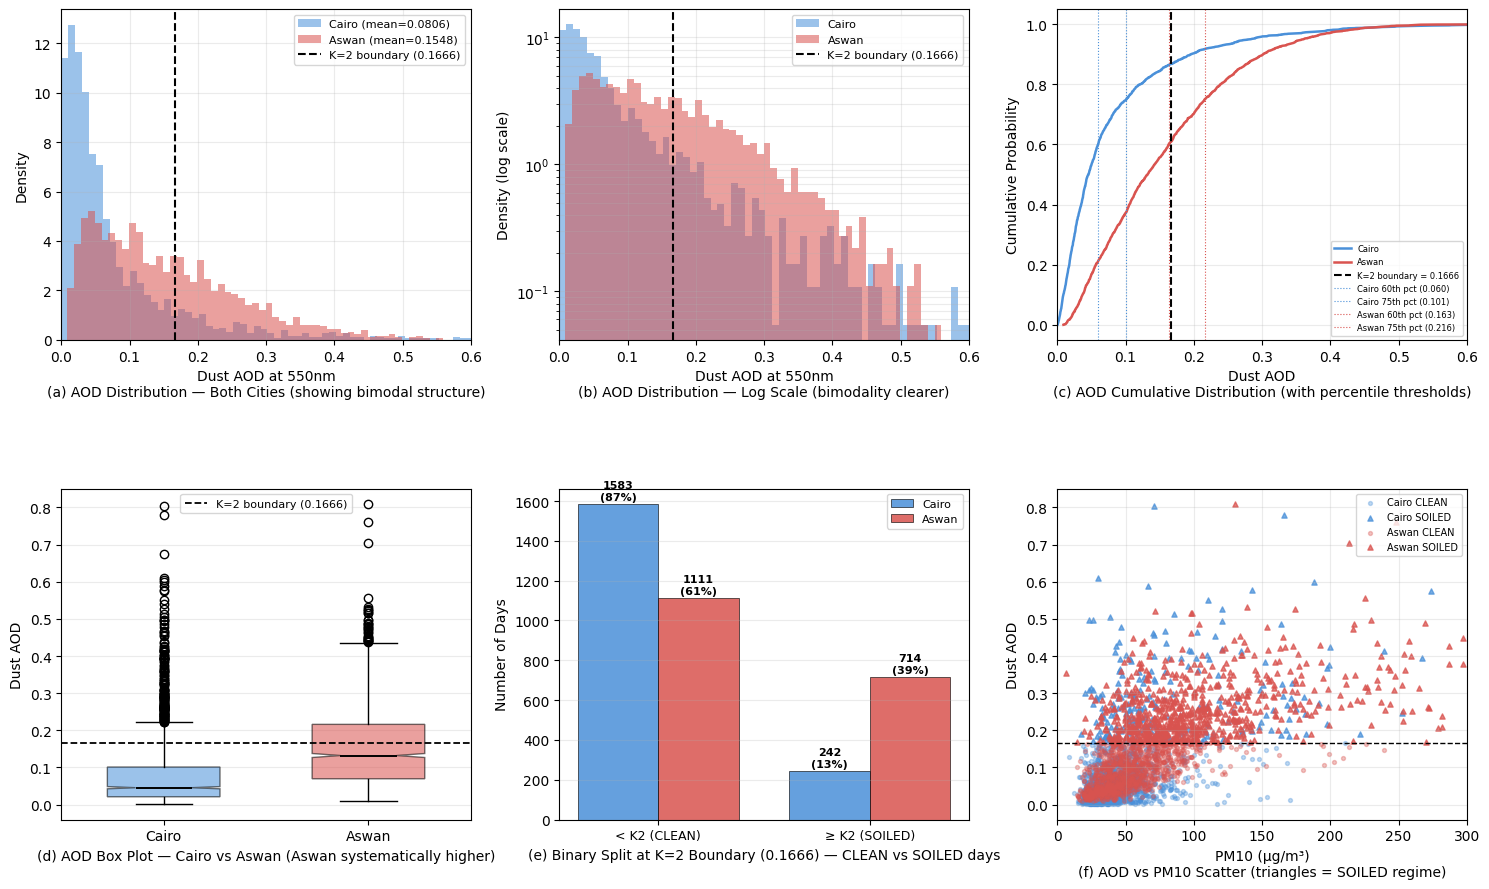

Saved: fig6_cams_aod_distribution.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(BASE_PATH + 'clean_data_2019_2023.csv')
cairo = df[df['city'] == 'Cairo']
aswan = df[df['city'] == 'Aswan']

C_CAIRO = '#4A90D9'   # blue
C_ASWAN = '#D9534F'   # red
K2_BOUNDARY = 0.1666

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# (a) Histograms — linear scale
ax = axes[0,0]
ax.hist(cairo['dust_aod'], bins=80, density=True, color=C_CAIRO,
        alpha=0.55, label=f"Cairo (mean={cairo['dust_aod'].mean():.4f})")
ax.hist(aswan['dust_aod'], bins=80, density=True, color=C_ASWAN,
        alpha=0.55, label=f"Aswan (mean={aswan['dust_aod'].mean():.4f})")
ax.axvline(K2_BOUNDARY, color='black', ls='--', lw=1.5,
           label=f'K=2 boundary ({K2_BOUNDARY:.4f})')
ax.set_xlim(0, 0.6); ax.set_ylabel('Density'); ax.set_xlabel('Dust AOD at 550nm')
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# (b) Histograms — log scale
ax = axes[0,1]
ax.hist(cairo['dust_aod'], bins=80, density=True, color=C_CAIRO,
        alpha=0.55, label='Cairo')
ax.hist(aswan['dust_aod'], bins=80, density=True, color=C_ASWAN,
        alpha=0.55, label='Aswan')
ax.axvline(K2_BOUNDARY, color='black', ls='--', lw=1.5,
           label=f'K=2 boundary ({K2_BOUNDARY:.4f})')
ax.set_xlim(0, 0.6); ax.set_yscale('log')
ax.set_ylabel('Density (log scale)'); ax.set_xlabel('Dust AOD at 550nm')
ax.legend(fontsize=8); ax.grid(alpha=0.25, which='both')

# (c) CDFs with percentile markers
ax = axes[0,2]
for d, color, name in [(cairo, C_CAIRO, 'Cairo'), (aswan, C_ASWAN, 'Aswan')]:
    x = np.sort(d['dust_aod'].values); y = np.arange(1, len(x)+1)/len(x)
    ax.plot(x, y, color=color, lw=1.8, label=name)
ax.axvline(K2_BOUNDARY, color='black', ls='--', lw=1.5,
           label=f'K=2 boundary = {K2_BOUNDARY:.4f}')
for d, color, name in [(cairo, C_CAIRO, 'Cairo'), (aswan, C_ASWAN, 'Aswan')]:
    p60 = np.percentile(d['dust_aod'], 60); p75 = np.percentile(d['dust_aod'], 75)
    ax.axvline(p60, color=color, ls=':', lw=0.8,
               label=f'{name} 60th pct ({p60:.3f})')
    ax.axvline(p75, color=color, ls=':', lw=0.8,
               label=f'{name} 75th pct ({p75:.3f})')
ax.set_xlim(0, 0.6); ax.set_ylabel('Cumulative Probability')
ax.set_xlabel('Dust AOD')
ax.legend(fontsize=6, loc='lower right'); ax.grid(alpha=0.25)

# (d) Box plot — Cairo vs Aswan
ax = axes[1,0]
bp = ax.boxplot([cairo['dust_aod'], aswan['dust_aod']],
                labels=['Cairo','Aswan'], patch_artist=True, notch=True,
                widths=0.55,
                medianprops=dict(color='black', lw=1.4))
for patch, color in zip(bp['boxes'], [C_CAIRO, C_ASWAN]):
    patch.set_facecolor(color); patch.set_alpha(0.55)
ax.axhline(K2_BOUNDARY, color='black', ls='--', lw=1.3,
           label=f'K=2 boundary ({K2_BOUNDARY:.4f})')
ax.set_ylabel('Dust AOD'); ax.legend(fontsize=8); ax.grid(alpha=0.25, axis='y')

# (e) Binary CLEAN / SOILED counts
ax = axes[1,1]
cnt_cairo = [(cairo['dust_aod'] < K2_BOUNDARY).sum(),
             (cairo['dust_aod'] >= K2_BOUNDARY).sum()]
cnt_aswan = [(aswan['dust_aod'] < K2_BOUNDARY).sum(),
             (aswan['dust_aod'] >= K2_BOUNDARY).sum()]
n_c = sum(cnt_cairo); n_a = sum(cnt_aswan)
x_pos = np.arange(2); w = 0.38
b1 = ax.bar(x_pos - w/2, cnt_cairo, w, color=C_CAIRO, alpha=0.85,
            edgecolor='black', lw=0.5, label='Cairo')
b2 = ax.bar(x_pos + w/2, cnt_aswan, w, color=C_ASWAN, alpha=0.85,
            edgecolor='black', lw=0.5, label='Aswan')
for bars, tot in [(b1, n_c), (b2, n_a)]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 12,
                f"{int(h)}\n({100*h/tot:.0f}%)",
                ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'< K2 (CLEAN)', f'≥ K2 (SOILED)'], fontsize=9)
ax.set_ylabel('Number of Days')
ax.legend(fontsize=8); ax.grid(alpha=0.25, axis='y')

# (f) AOD vs PM10 scatter with SOILED triangles
ax = axes[1,2]
for d, color, name in [(cairo, C_CAIRO, 'Cairo'), (aswan, C_ASWAN, 'Aswan')]:
    clean_mask  = d['dust_aod'] <  K2_BOUNDARY
    soiled_mask = d['dust_aod'] >= K2_BOUNDARY
    ax.scatter(d.loc[clean_mask,'pm10_ugm3'],  d.loc[clean_mask,'dust_aod'],
               s=8, color=color, alpha=0.35, marker='o', label=f'{name} CLEAN')
    ax.scatter(d.loc[soiled_mask,'pm10_ugm3'], d.loc[soiled_mask,'dust_aod'],
               s=14, color=color, alpha=0.75, marker='^', label=f'{name} SOILED')
ax.axhline(K2_BOUNDARY, color='black', ls='--', lw=1.0)
ax.set_xlim(0, 300); ax.set_xlabel('PM10 (μg/m³)'); ax.set_ylabel('Dust AOD')
ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.25)

# Captions under each panel
labels = [
    '(a) AOD Distribution — Both Cities (showing bimodal structure)',
    '(b) AOD Distribution — Log Scale (bimodality clearer)',
    '(c) AOD Cumulative Distribution (with percentile thresholds)',
    '(d) AOD Box Plot — Cairo vs Aswan (Aswan systematically higher)',
    '(e) Binary Split at K=2 Boundary (0.1666) — CLEAN vs SOILED days',
    '(f) AOD vs PM10 Scatter (triangles = SOILED regime)',
]
for ax, cap in zip(axes.flat, labels):
    ax.set_title('')
    # Overwrite x-label only for panels that need the caption to be the bottom text
    current_xlabel = ax.get_xlabel()
    # For panels with their own data axis label, append caption on a new line
    if current_xlabel:
        ax.set_xlabel(f'{current_xlabel}\n{cap}', fontsize=10, labelpad=4)
    else:
        ax.set_xlabel(cap, fontsize=10, labelpad=4)

plt.tight_layout()
plt.subplots_adjust(hspace=0.45)
plt.savefig(BASE_PATH + 'fig6_cams_aod_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig6_cams_aod_distribution.png')

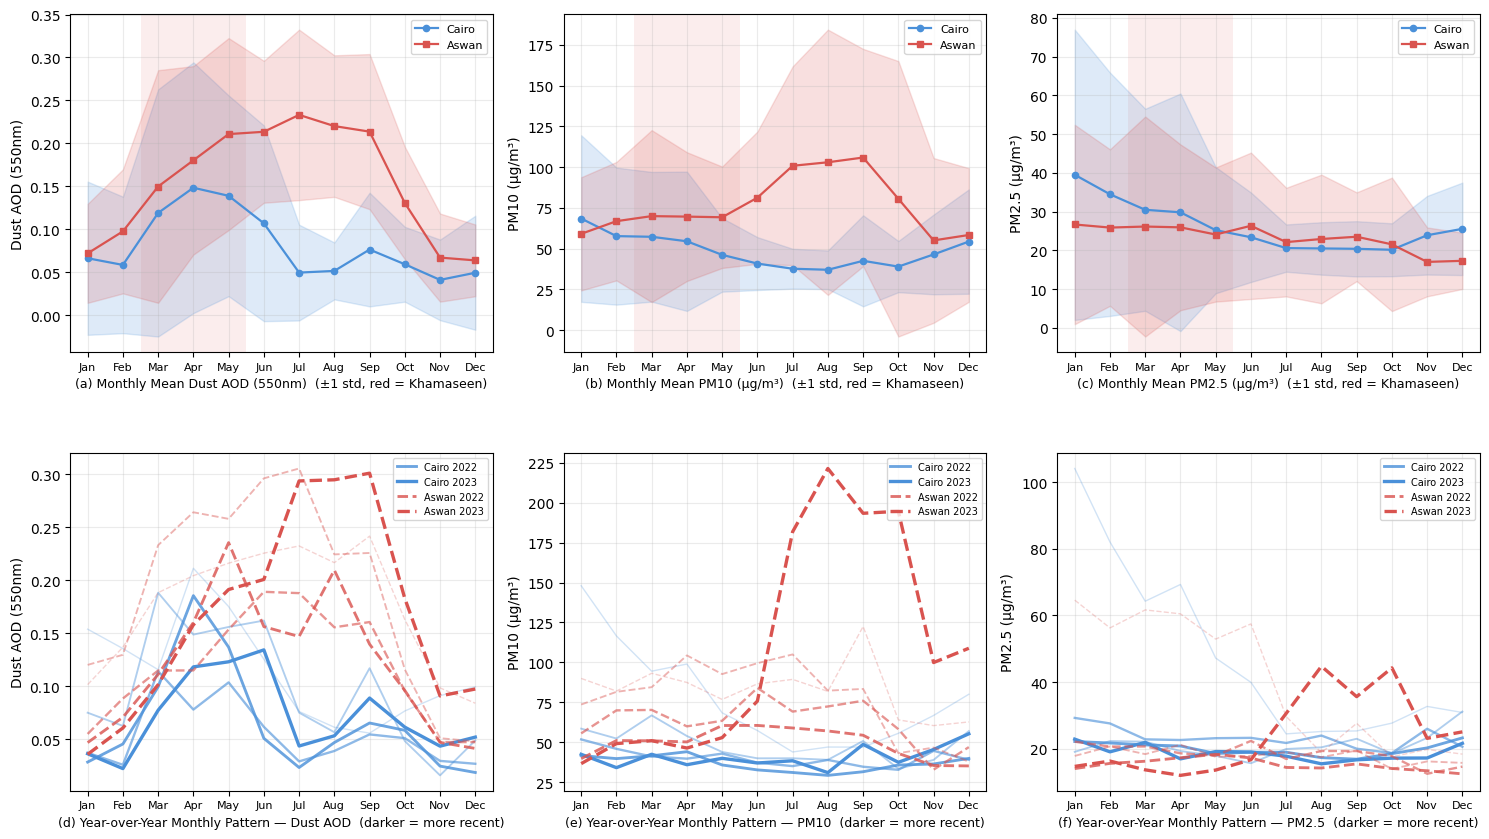

Saved: fig7_cams_monthly_climatology.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(BASE_PATH + 'clean_data_2019_2023.csv')
df['time']  = pd.to_datetime(df['time'])
df['month'] = df['time'].dt.month
df['year']  = df['time'].dt.year

cairo = df[df['city'] == 'Cairo']
aswan = df[df['city'] == 'Aswan']

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

C_CAIRO = '#4A90D9'
C_ASWAN = '#D9534F'
KHAM_X  = [3, 4, 5]
KHAM_C  = '#D9534F'
YEARS   = sorted(df['year'].unique())

def monthly_stats(d, col):
    g = d.groupby('month')[col]
    return g.mean(), g.std()

def shade_khamaseen(ax):
    for m in KHAM_X:
        ax.axvspan(m - 0.5, m + 0.5, color=KHAM_C, alpha=0.10, lw=0)

def plot_band(ax, mean, std, color, label, marker='o'):
    ax.plot(range(1,13), mean.values, '-', marker=marker, color=color,
            lw=1.6, ms=4.5, label=label)
    ax.fill_between(range(1,13),
                    mean.values - std.values,
                    mean.values + std.values,
                    color=color, alpha=0.18)

def yearly_lines(ax, d, col, color, name):
    n = len(YEARS)
    for i, y in enumerate(YEARS):
        sub = d[d['year'] == y]
        mm  = sub.groupby('month')[col].mean()
        if not len(mm): continue
        alpha = 0.25 + 0.75 * (i / max(n-1, 1))
        lw    = 1.0 + 1.4 * (i / max(n-1, 1))
        ls    = '-' if name == 'Cairo' else '--'
        lbl = f'{name} {y}' if i >= n-2 else None
        ax.plot(mm.index, mm.values,
                color=color, alpha=alpha, lw=lw, ls=ls, label=lbl)

# --- Figure ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))

vars_top = [
    ('dust_aod',  'Dust AOD (550nm)',     '(a) Monthly Mean Dust AOD (550nm)  (±1 std, red = Khamaseen)'),
    ('pm10_ugm3', 'PM10 (μg/m³)',         '(b) Monthly Mean PM10 (μg/m³)  (±1 std, red = Khamaseen)'),
    ('pm25_ugm3', 'PM2.5 (μg/m³)',        '(c) Monthly Mean PM2.5 (μg/m³)  (±1 std, red = Khamaseen)'),
]
vars_bot = [
    ('dust_aod',  'Dust AOD (550nm)',     '(d) Year-over-Year Monthly Pattern — Dust AOD  (darker = more recent)'),
    ('pm10_ugm3', 'PM10 (μg/m³)',         '(e) Year-over-Year Monthly Pattern — PM10  (darker = more recent)'),
    ('pm25_ugm3', 'PM2.5 (μg/m³)',        '(f) Year-over-Year Monthly Pattern — PM2.5  (darker = more recent)'),
]

# Top row — climatology
for ax, (col, ylab, _) in zip(axes[0,:], vars_top):
    shade_khamaseen(ax)
    plot_band(ax, *monthly_stats(cairo, col), C_CAIRO, 'Cairo')
    plot_band(ax, *monthly_stats(aswan, col), C_ASWAN, 'Aswan', marker='s')
    ax.set_ylabel(ylab); ax.legend(fontsize=8); ax.grid(alpha=0.25)

# Bottom row — year-over-year
for ax, (col, ylab, _) in zip(axes[1,:], vars_bot):
    yearly_lines(ax, cairo, col, C_CAIRO, 'Cairo')
    yearly_lines(ax, aswan, col, C_ASWAN, 'Aswan')
    ax.set_ylabel(ylab); ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.25)

# Month axis + captions
all_caps = [c[2] for c in vars_top] + [c[2] for c in vars_bot]
for ax, cap in zip(axes.flat, all_caps):
    ax.set_title('')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTHS, fontsize=8)
    ax.set_xlim(0.5, 12.5)
    ax.set_xlabel(cap, fontsize=9, labelpad=4)

plt.tight_layout()
plt.subplots_adjust(hspace=0.30)
plt.savefig(BASE_PATH + 'fig7_cams_monthly_climatology.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig7_cams_monthly_climatology.png')

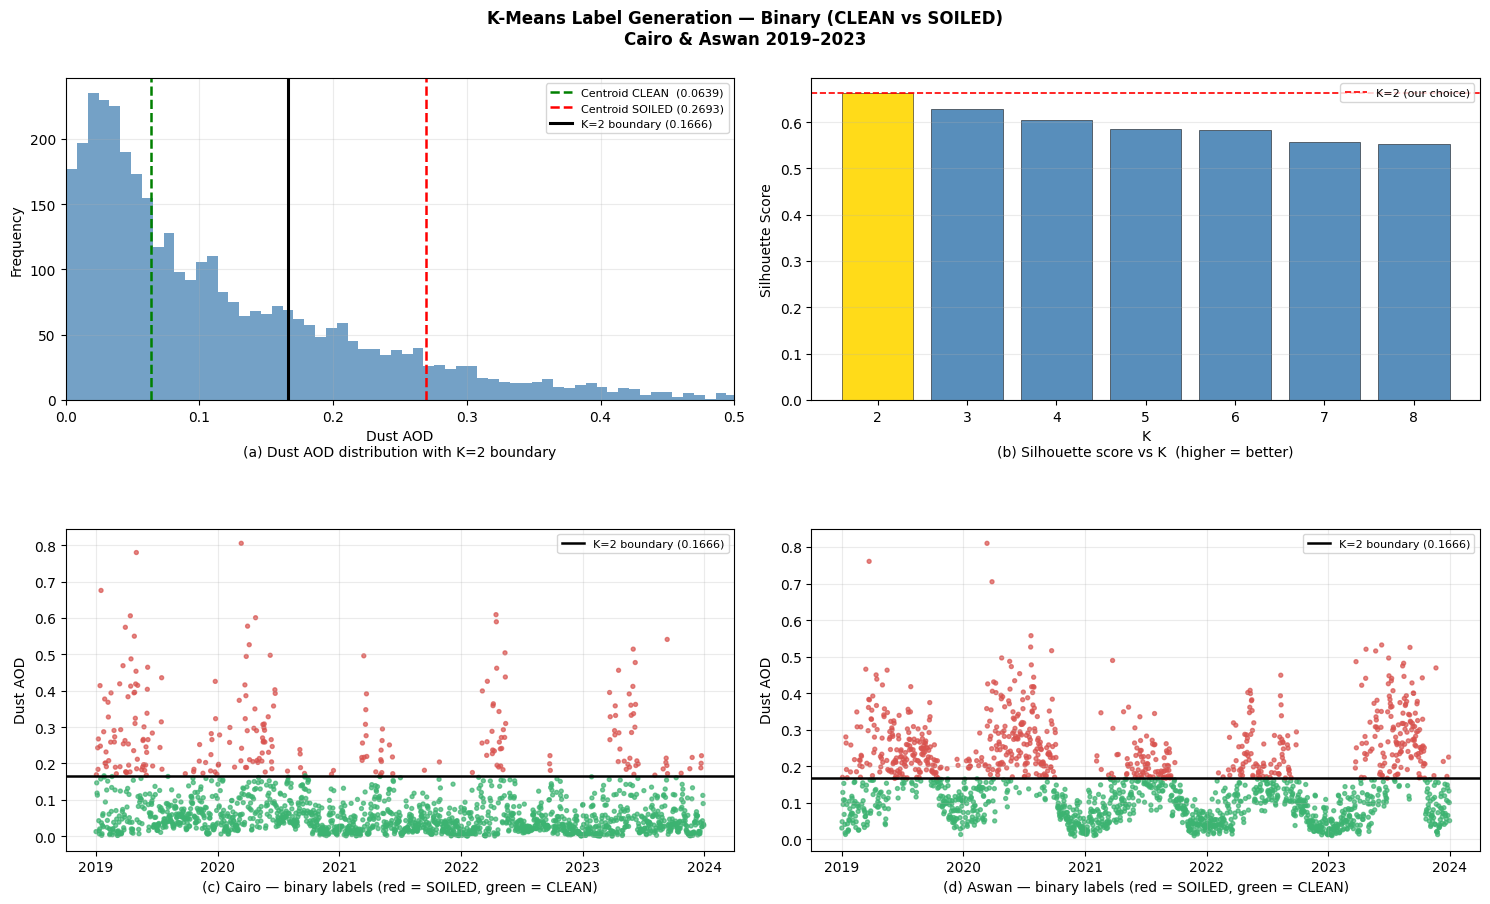


K=2 centroids : CLEAN=0.0639,  SOILED=0.2693
K=2 boundary  : 0.1666
CLEAN  :  2694  (73.8%)
SOILED :   956  (26.2%)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv(BASE_PATH + 'clean_data_2019_2023.csv')
df['time'] = pd.to_datetime(df['time'])

aod    = df['dust_aod'].values
aod_2d = aod.reshape(-1, 1)

# K-Means on 1-D AOD for K = 2..8
K_range = range(2, 9)
silhouettes, centroids_by_k = [], {}
for k in K_range:
    km   = KMeans(n_clusters=k, random_state=42, n_init=20).fit(aod_2d)
    sil  = silhouette_score(aod_2d, km.labels_)
    silhouettes.append(sil)
    centroids_by_k[k] = sorted(km.cluster_centers_.flatten())

c_low, c_high = centroids_by_k[2]
K2_BOUNDARY   = (c_low + c_high) / 2
labels_binary = (aod >= K2_BOUNDARY).astype(int)   # 0=CLEAN, 1=SOILED

C_CLEAN = '#3CB371'
C_SOIL  = '#D9534F'

# --- Figure ---
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('K-Means Label Generation — Binary (CLEAN vs SOILED)\n'
             'Cairo & Aswan 2019–2023',
             fontsize=12, fontweight='bold', y=1.00)

# (a) Histogram with centroids and boundary
ax = axes[0,0]
ax.hist(aod, bins=100, color='steelblue', alpha=0.75, edgecolor='none')
ax.axvline(c_low,        color='green', ls='--', lw=1.8,
           label=f'Centroid CLEAN  ({c_low:.4f})')
ax.axvline(c_high,       color='red',   ls='--', lw=1.8,
           label=f'Centroid SOILED ({c_high:.4f})')
ax.axvline(K2_BOUNDARY,  color='black', ls='-',  lw=2.2,
           label=f'K=2 boundary ({K2_BOUNDARY:.4f})')
ax.set_xlim(0, 0.5); ax.set_xlabel('Dust AOD'); ax.set_ylabel('Frequency')
ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.set_title('(a) Dust AOD distribution with K=2 boundary', fontsize=10)

# (b) Silhouette bars, K=2 highlighted
ax = axes[0,1]
colors_sil = ['gold' if k == 2 else 'steelblue' for k in K_range]
ax.bar(list(K_range), silhouettes, color=colors_sil, alpha=0.9,
       edgecolor='black', lw=0.4)
ax.axhline(silhouettes[0], color='red', ls='--', lw=1.2,
           label='K=2 (our choice)')
ax.set_xlabel('K'); ax.set_ylabel('Silhouette Score')
ax.legend(fontsize=8); ax.grid(alpha=0.25, axis='y')
ax.set_title('(b) Silhouette score vs K  (higher = better)', fontsize=10)

# (c) Cairo — binary labels timeline
ax = axes[1,0]
mask = (df['city'] == 'Cairo').values
colors_c = [C_SOIL if x == 1 else C_CLEAN for x in labels_binary[mask]]
ax.scatter(df.loc[mask, 'time'], df.loc[mask, 'dust_aod'],
           c=colors_c, s=8, alpha=0.7)
ax.axhline(K2_BOUNDARY, color='black', lw=1.8,
           label=f'K=2 boundary ({K2_BOUNDARY:.4f})')
ax.set_ylabel('Dust AOD'); ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.25)
ax.set_title('(c) Cairo — binary labels (red = SOILED, green = CLEAN)',
             fontsize=10)

# (d) Aswan — binary labels timeline
ax = axes[1,1]
mask = (df['city'] == 'Aswan').values
colors_a = [C_SOIL if x == 1 else C_CLEAN for x in labels_binary[mask]]
ax.scatter(df.loc[mask, 'time'], df.loc[mask, 'dust_aod'],
           c=colors_a, s=8, alpha=0.7)
ax.axhline(K2_BOUNDARY, color='black', lw=1.8,
           label=f'K=2 boundary ({K2_BOUNDARY:.4f})')
ax.set_ylabel('Dust AOD'); ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.25)
ax.set_title('(d) Aswan — binary labels (red = SOILED, green = CLEAN)',
             fontsize=10)

# Convert all titles to below-panel captions
for ax in axes.flat:
    cap = ax.get_title()
    ax.set_title('')
    ax.set_xlabel(f"{ax.get_xlabel()}\n{cap}".strip(),
                  fontsize=10, labelpad=4)

plt.tight_layout()
plt.subplots_adjust(hspace=0.40)
plt.savefig(BASE_PATH + 'fig8_kmeans_binary_labeling.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Diagnostics
n_clean  = int((labels_binary == 0).sum())
n_soiled = int((labels_binary == 1).sum())
print(f'\nK=2 centroids : CLEAN={c_low:.4f},  SOILED={c_high:.4f}')
print(f'K=2 boundary  : {K2_BOUNDARY:.4f}')
print(f'CLEAN  : {n_clean:>5d}  ({100*n_clean/len(labels_binary):.1f}%)')
print(f'SOILED : {n_soiled:>5d}  ({100*n_soiled/len(labels_binary):.1f}%)')

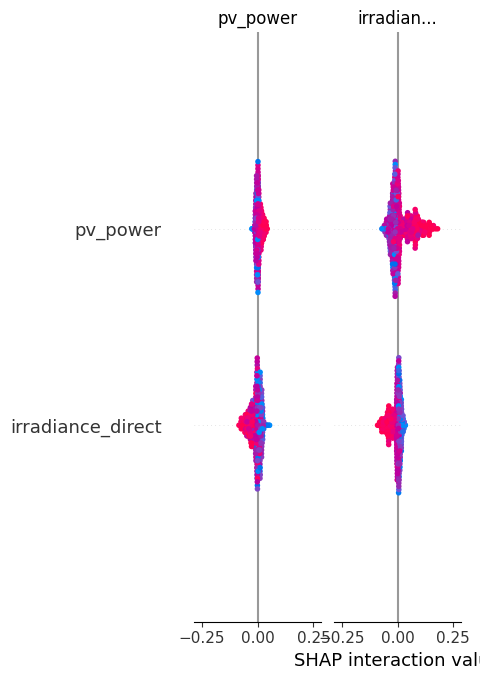

In [ ]:
!pip install shap -q
import shap
explainer   = shap.TreeExplainer(results['Random Forest']['model'])
shap_values = explainer.shap_values(X_test.values)
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.savefig(BASE_PATH + 'shap_summary.png', dpi=150, bbox_inches='tight')